# CS 559 

## A. Setup & Data Loading  -  EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin
import joblib
print(f"joblib version: {joblib.__version__}  (team members need matching version)")
warnings.filterwarnings('ignore')
# Reproducibility — required by project spec (Section 6.2)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 11
sns.set_style('whitegrid')

print("Libraries loaded")

joblib version: 1.5.3  (team members need matching version)
Libraries loaded


In [2]:
df = pd.read_csv('train_data.csv')
df.columns = df.columns.str.strip()  # strip leading whitespace in column names
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head(3)

Shape: (5807, 97)
Memory: 4.30 MB


,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.450397,0.504034,0.506986,0.594640,0.594640,0.998906,0.797293,0.809239,...,0.780554,0.004919,0.623634,0.594641,0.838869,0.279036,0.026788,0.565144,1,0.032464
1,1,0,0.530005,0.572885,0.574763,0.605695,0.605558,0.999058,0.797512,0.809399,...,0.819963,0.005968,0.624171,0.605690,0.841869,0.279040,0.026801,0.565205,1,0.032442
2,2,0,0.571150,0.620148,0.624177,0.612275,0.612282,0.999163,0.797654,0.809533,...,0.839128,0.006022,0.625306,0.612271,0.843294,0.278927,0.026816,0.565276,1,0.033034


In [3]:
# Split into target, index, and features
y   = df['Bankrupt?'].copy()
idx = df['Index'].copy()
X   = df.drop(columns=['Index', 'Bankrupt?'])

# Drop the single zero-variance feature identified in initial EDA
zero_var_cols = X.var()[X.var() < 1e-6].index.tolist()
print(f"Zero-variance features to drop: {zero_var_cols}")
X = X.drop(columns=zero_var_cols)

print(f"\nFeature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

Zero-variance features to drop: ['Net Income Flag']

Feature matrix X: (5807, 94)
Target vector y: (5807,)
Missing values: 0


## B. Target Analysis

In [4]:
counts = y.value_counts()
prop = y.value_counts(normalize=True)

print("\nTARGET DISTRIBUTION")
print(f"Not Bankrupt (y=0): {counts[0]:>5} ({prop[0]*100:5.2f}%)")
print(f"Bankrupt     (y=1): {counts[1]:>5} ({prop[1]*100:5.2f}%)")
print(f"Imbalance ratio:   1 bankrupt for every {counts[0]/counts[1]:.1f} healthy firms")
print(f"Total companies:   {len(y)}")


TARGET DISTRIBUTION
Not Bankrupt (y=0):  5609 (96.59%)
Bankrupt     (y=1):   198 ( 3.41%)
Imbalance ratio:   1 bankrupt for every 28.3 healthy firms
Total companies:   5807


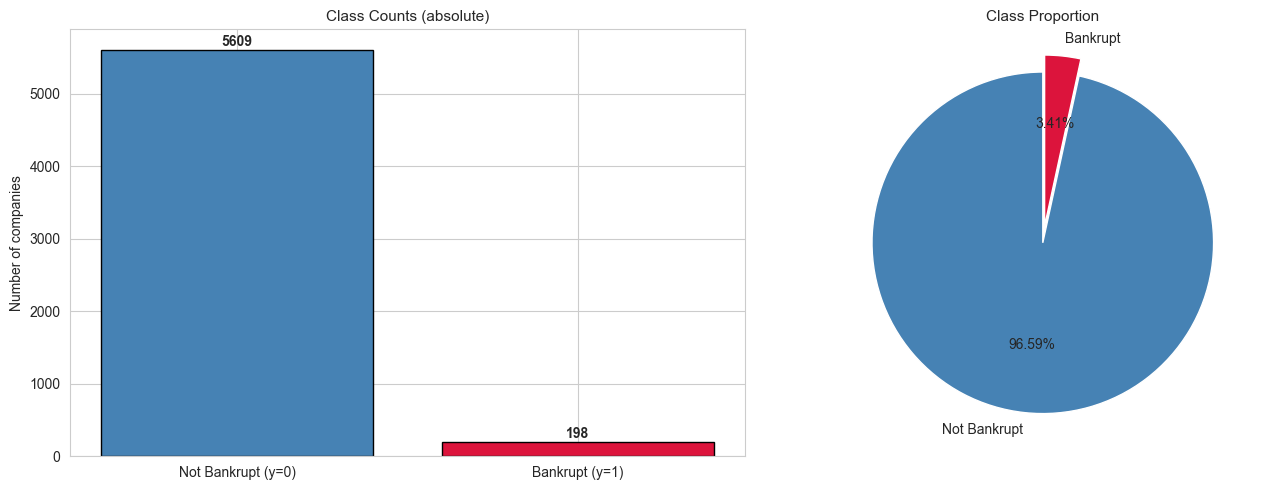

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart with counts
bars = axes[0].bar(['Not Bankrupt (y=0)', 'Bankrupt (y=1)'], counts.values,
                    color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Counts (absolute)')
axes[0].set_ylabel('Number of companies')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, str(v),
                 ha='center', fontweight='bold')

# Pie with proportions
axes[1].pie(counts.values, labels=['Not Bankrupt', 'Bankrupt'],
            autopct='%1.2f%%', colors=['steelblue', 'crimson'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

## C. Feature Scale Diagnostics

In [6]:
# Summary statistics for every feature
scale_summary = pd.DataFrame({
    'min': X.min(),
    'max': X.max(),
    'mean': X.mean(),
    'median': X.median(),
    'std': X.std(),
    'range': X.max() - X.min()
})

# Features outside the normal [0, 1.5] range
extreme = scale_summary[(scale_summary['min'] < 0) | (scale_summary['max'] > 1.5)]
normal  = scale_summary[(scale_summary['min'] >= 0) & (scale_summary['max'] <= 1.5)]

print(f"Features in normal range (0 to 1.5):  {len(normal):>2}")
print(f"Features with extreme values:         {len(extreme):>2}")
print(f"Total:                                {len(scale_summary):>2}")

Features in normal range (0 to 1.5):  70
Features with extreme values:         24
Total:                                94


In [7]:
# Show the extreme features — these are the ones that will dominate KMeans distances if unscaled
print("EXTREME-SCALE FEATURES (min, max, range):\n")
extreme_sorted = extreme.sort_values('max', ascending=False)
for feat, row in extreme_sorted.iterrows():
    print(f"  {feat[:48]:<50} max={row['max']:>12.2e}  range={row['range']:>12.2e}")

EXTREME-SCALE FEATURES (min, max, range):

  Cash Turnover Rate                                 max=    1.00e+10  range=    1.00e+10
  Current Asset Turnover Rate                        max=    1.00e+10  range=    1.00e+10
  Quick Asset Turnover Rate                          max=    1.00e+10  range=    1.00e+10
  Operating Expense Rate                             max=    9.99e+09  range=    9.99e+09
  Inventory Turnover Rate (times)                    max=    9.99e+09  range=    9.99e+09
  Total Asset Growth Rate                            max=    9.99e+09  range=    9.99e+09
  Fixed Assets Turnover Frequency                    max=    9.99e+09  range=    9.99e+09
  Research and development expense rate              max=    9.98e+09  range=    9.98e+09
  Total debt/Total net worth                         max=    9.94e+09  range=    9.94e+09
  Inventory/Current Liability                        max=    9.91e+09  range=    9.91e+09
  Total assets to GNP price                          max=

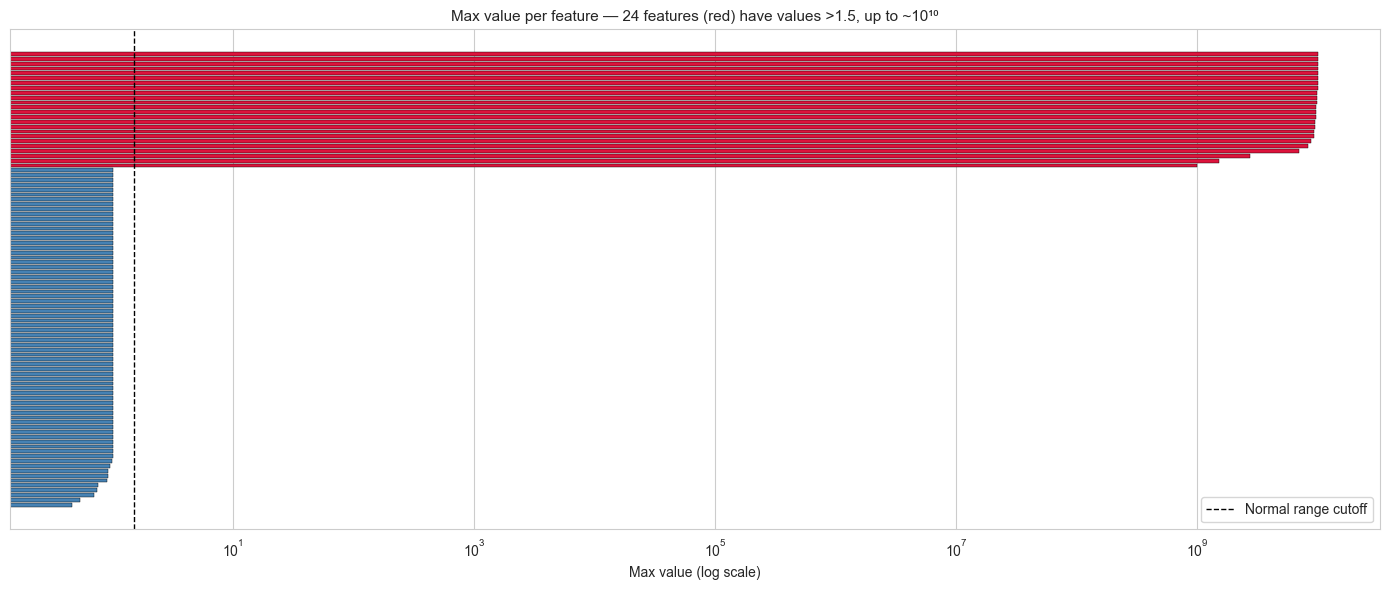

In [8]:
# Visualize the scale disparity — log-scale the max value of every feature
fig, ax = plt.subplots(figsize=(14, 6))

max_vals = X.max().sort_values()
colors = ['crimson' if v > 1.5 else 'steelblue' for v in max_vals.values]

ax.barh(range(len(max_vals)), max_vals.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xscale('log')
ax.set_yticks([])
ax.set_xlabel('Max value (log scale)')
ax.set_title(f'Max value per feature — {len(extreme)} features (red) have values >1.5, up to ~10¹⁰')
ax.axvline(1.5, color='black', linestyle='--', linewidth=1, label='Normal range cutoff')
ax.legend()
plt.tight_layout()
plt.show()

## D. Distribution Shape — Skewness & Kurtosis

In [9]:
shape_stats = pd.DataFrame({
    'skew': X.skew(),
    'kurtosis': X.kurt(),
    'abs_skew': X.skew().abs()
}).sort_values('abs_skew', ascending=False)

heavy_skew = shape_stats[shape_stats['abs_skew'] > 3]
moderate   = shape_stats[(shape_stats['abs_skew'] > 1) & (shape_stats['abs_skew'] <= 3)]
near_norm  = shape_stats[shape_stats['abs_skew'] <= 1]

print(f"Heavy skew (|skew| > 3):    {len(heavy_skew):>2} features")
print(f"Moderate skew (1 < |s| ≤3): {len(moderate):>2} features")
print(f"Near normal (|skew| ≤ 1):   {len(near_norm):>2} features")

Heavy skew (|skew| > 3):    66 features
Moderate skew (1 < |s| ≤3): 16 features
Near normal (|skew| ≤ 1):   12 features


In [10]:
print("TOP 15 MOST SKEWED FEATURES\n")
print(shape_stats[['skew', 'kurtosis']].head(15).round(2).to_string())

TOP 15 MOST SKEWED FEATURES

                                          skew  kurtosis
Revenue per person                       76.20   5807.00
Current Ratio                            76.20   5807.00
Fixed Assets to Assets                   76.20   5807.00
Total income/Total expense               75.99   5785.61
Net Value Growth Rate                    74.09   5573.57
Contingent liabilities/Net worth         73.88   5565.02
Realized Sales Gross Profit Growth Rate  72.69   5441.02
Operating Profit Growth Rate            -66.29   4853.60
Operating Profit Rate                   -64.96   4450.32
Continuous Net Profit Growth Rate        61.98   4601.34
Total Asset Return Growth Rate Ratio     57.81   4335.54
Quick Assets/Current Liability           54.36   2971.30
After-tax net Interest Rate             -50.51   2710.08
Pre-tax net Interest Rate               -50.35   2761.41
Continuous interest rate (after tax)    -49.53   2697.68


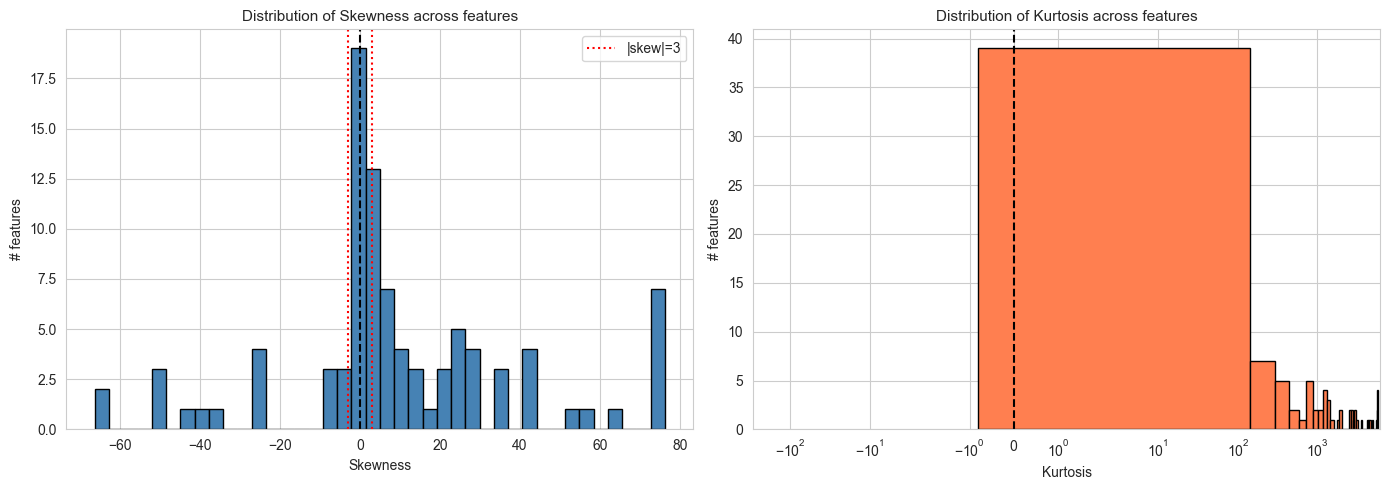

In [11]:
# Visualize skewness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(shape_stats['skew'], bins=40, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].axvline(3, color='red', linestyle=':', label='|skew|=3')
axes[0].axvline(-3, color='red', linestyle=':')
axes[0].set_title('Distribution of Skewness across features')
axes[0].set_xlabel('Skewness')
axes[0].set_ylabel('# features')
axes[0].legend()

axes[1].hist(shape_stats['kurtosis'], bins=40, color='coral', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution of Kurtosis across features')
axes[1].set_xlabel('Kurtosis')
axes[1].set_ylabel('# features')
axes[1].set_xscale('symlog')

plt.tight_layout()
plt.show()

**Interpretation.** About 2/3 of features are heavily skewed. Raw KMeans will produce garbage clusters on this data. We need either a power transform (e.g., Yeo-Johnson) or to rely on PCA — which, after proper scaling, mitigates individual-feature skewness because principal components are linear combinations that average out irregularities.

## E. Correlation Structure

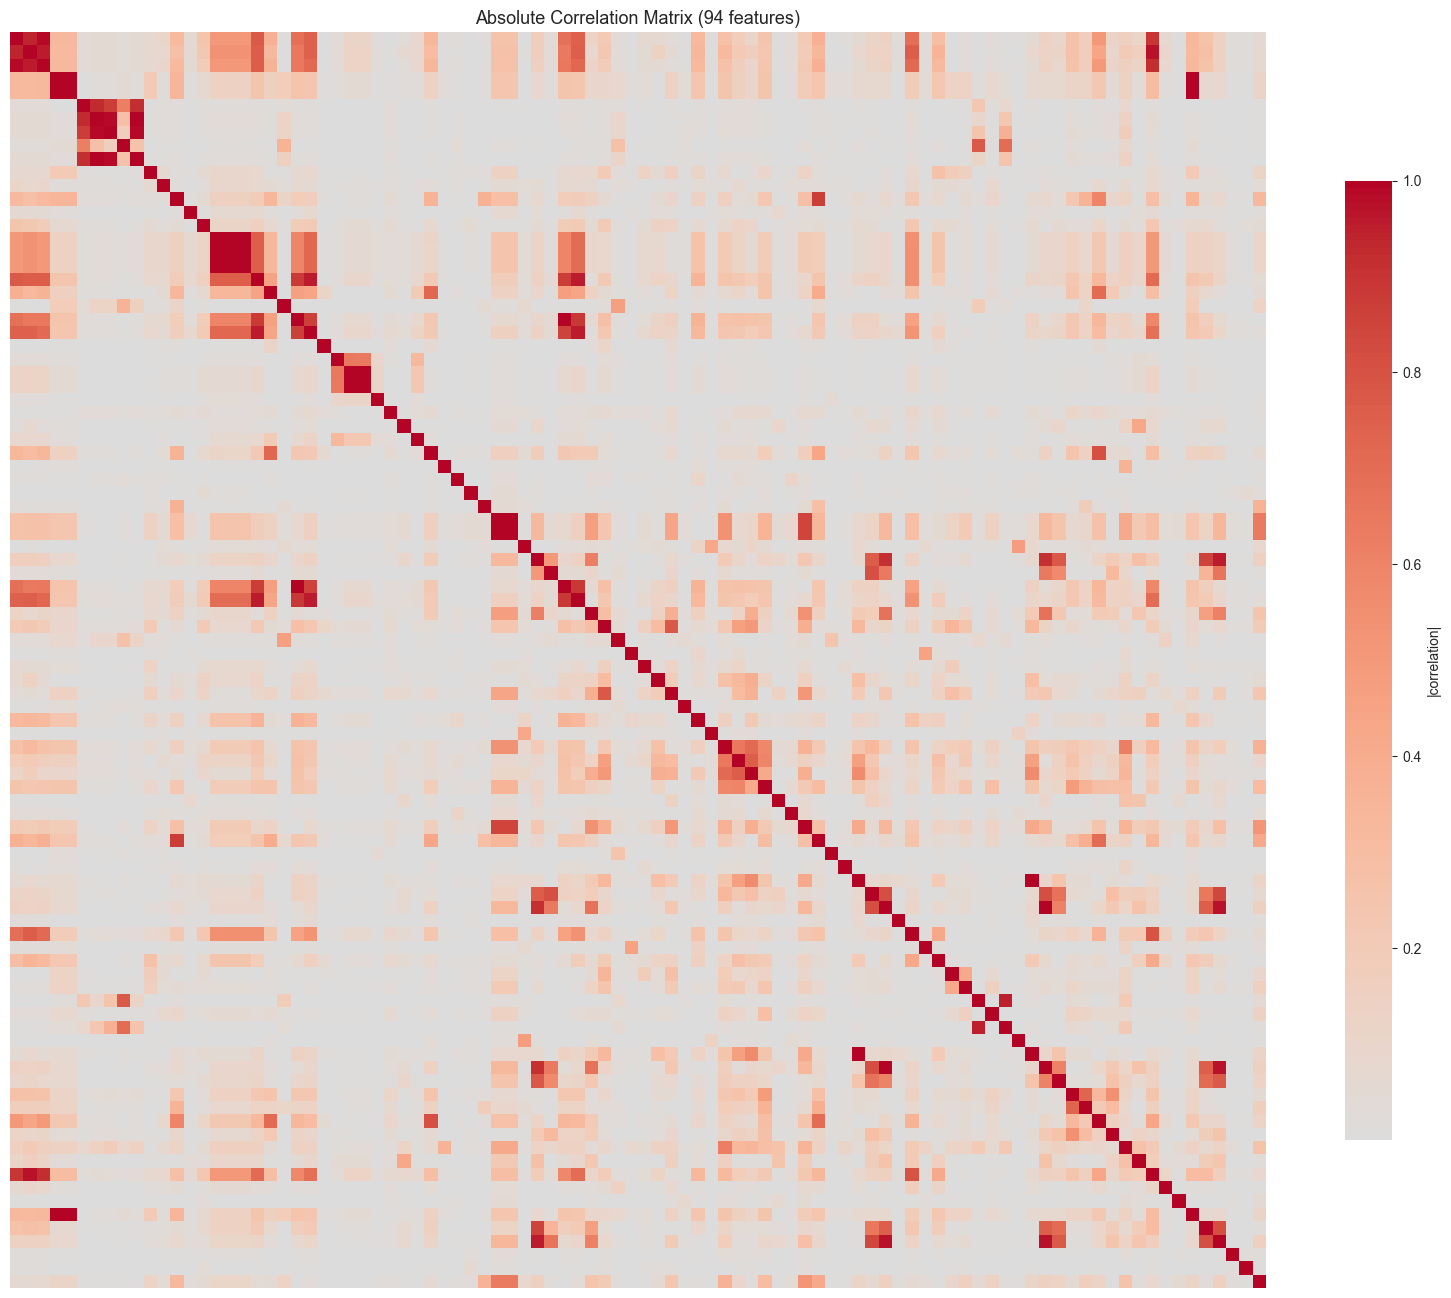

In [12]:
corr = X.corr().abs()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7, 'label': '|correlation|'},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title(f'Absolute Correlation Matrix ({X.shape[1]} features)', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Upper-triangle extraction of highly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pairs = []
for i in range(len(upper.columns)):
    for j in range(i+1, len(upper.columns)):
        val = upper.iloc[i, j]
        if pd.notna(val) and val > 0.90:
            pairs.append((upper.index[i], upper.columns[j], val))

pairs_df = pd.DataFrame(pairs, columns=['Feature A', 'Feature B', '|r|'])
pairs_df = pairs_df.sort_values('|r|', ascending=False).reset_index(drop=True)

print(f"Pairs with |r| > 0.99: {(pairs_df['|r|'] > 0.99).sum()}")
print(f"Pairs with |r| > 0.95: {(pairs_df['|r|'] > 0.95).sum()}")
print(f"Pairs with |r| > 0.90: {(pairs_df['|r|'] > 0.90).sum()}")
print("\nTop 25 highly correlated pairs:")
print(pairs_df.head(25).round(3).to_string())

Pairs with |r| > 0.99: 12
Pairs with |r| > 0.95: 24
Pairs with |r| > 0.90: 30

Top 25 highly correlated pairs:
                                                  Feature A                                          Feature B    |r|
0                             Current Liabilities/Liability                     Current Liability to Liability  1.000
1                                Current Liabilities/Equity                        Current Liability to Equity  1.000
2                                              Debt ratio %                                   Net worth/Assets  1.000
3                                    Operating Gross Margin                              Gross Profit to Sales  1.000
4                                   Net Value Per Share (A)                            Net Value Per Share (C)  1.000
5                                    Operating Gross Margin                        Realized Sales Gross Margin  1.000
6                               Realized Sales Gross Margin    

In [14]:
# Drop one feature from each |r|>0.95 pair, keeping the one with higher variance
THRESHOLD = 0.95
to_drop = set()
strong_pairs = pairs_df[pairs_df['|r|'] > THRESHOLD]

for _, row in strong_pairs.iterrows():
    a, b = row['Feature A'], row['Feature B']
    if a in to_drop or b in to_drop:
        continue
    # Keep the one with higher variance (more information content)
    to_drop.add(a if X[a].var() < X[b].var() else b)

X_pruned = X.drop(columns=list(to_drop))
print(f"Features dropped (|r| > {THRESHOLD}): {len(to_drop)}")
print(f"Remaining features: {X_pruned.shape[1]}\n")
print("Dropped features:")
for f in sorted(to_drop):
    print(f"  - {f}")

Features dropped (|r| > 0.95): 19
Remaining features: 75

Dropped features:
  - After-tax Net Profit Growth Rate
  - Continuous interest rate (after tax)
  - Current Liabilities/Equity
  - Current Liability to Equity
  - Current Liability to Liability
  - Gross Profit to Sales
  - Liability to Equity
  - Net Income to Total Assets
  - Net Value Per Share (A)
  - Net Value Per Share (B)
  - Net profit before tax/Paid-in capital
  - Net worth/Assets
  - Operating profit/Paid-in capital
  - Persistent EPS in the Last Four Seasons
  - Pre-tax net Interest Rate
  - ROA(B) before interest and depreciation after tax
  - ROA(C) before interest and depreciation before interest
  - Realized Sales Gross Margin
  - Working capitcal Turnover Rate


## F. Class Separation — Statistical Tests

In [15]:
# Compute class-conditional stats for ALL features
mean_by_class = X_pruned.groupby(y).mean().T
mean_by_class.columns = ['mean_healthy', 'mean_bankrupt']
mean_by_class['mean_diff']     = mean_by_class['mean_bankrupt'] - mean_by_class['mean_healthy']
mean_by_class['abs_mean_diff'] = mean_by_class['mean_diff'].abs()

# Cohen's d (standardized effect size)
def cohens_d(feature):
    x0 = X_pruned.loc[y==0, feature]
    x1 = X_pruned.loc[y==1, feature]
    pooled_std = np.sqrt((x0.var()*(len(x0)-1) + x1.var()*(len(x1)-1)) / (len(x0)+len(x1)-2))
    if pooled_std == 0:
        return 0.0
    return (x1.mean() - x0.mean()) / pooled_std

mean_by_class['cohens_d']     = [cohens_d(f) for f in mean_by_class.index]
mean_by_class['abs_cohens_d'] = mean_by_class['cohens_d'].abs()

# Mann-Whitney U test for every feature
pvals = []
for f in mean_by_class.index:
    try:
        _, p = stats.mannwhitneyu(X_pruned.loc[y==0, f], X_pruned.loc[y==1, f],
                                   alternative='two-sided')
    except ValueError:
        p = 1.0
    pvals.append(p)
mean_by_class['mw_pvalue']    = pvals
mean_by_class['neg_log10_p']  = -np.log10(np.maximum(mean_by_class['mw_pvalue'], 1e-300))

class_sep = mean_by_class.sort_values('abs_cohens_d', ascending=False)

print("TOP 20 MOST DISCRIMINATIVE FEATURES (by Cohen's d)\n")
display_cols = ['mean_healthy', 'mean_bankrupt', 'cohens_d', 'mw_pvalue']
print(class_sep[display_cols].head(20).round(4).to_string())

TOP 20 MOST DISCRIMINATIVE FEATURES (by Cohen's d)

                                             mean_healthy  mean_bankrupt  cohens_d  mw_pvalue
ROA(A) before interest and % after tax             0.5623         0.4613   -1.6032        0.0
Debt ratio %                                       0.1105         0.1871    1.4587        0.0
Retained Earnings to Total Assets                  0.9361         0.9062   -1.3933        0.0
Per Share Net profit before tax (Yuan ¥)           0.1858         0.1487   -1.1039        0.0
Working Capital to Total Assets                    0.8159         0.7519   -1.0997        0.0
Current Liability to Assets                        0.0886         0.1430    1.0963        0.0
Borrowing dependency                               0.3740         0.3909    1.0900        0.0
Net Income to Stockholder's Equity                 0.8409         0.8257   -0.9986        0.0
Equity to Long-term Liability                      0.1150         0.1314    0.9767        0.0
Current 

In [16]:
# How many features are statistically significant (Bonferroni-corrected)?
n_features = X_pruned.shape[1]
alpha = 0.05 / n_features   # Bonferroni correction

significant = class_sep[class_sep['mw_pvalue'] < alpha]
print(f"Features significant at Bonferroni α={alpha:.2e}: {len(significant)} / {n_features}")
print(f"Features with |Cohen's d| > 0.5 (medium effect): {(class_sep['abs_cohens_d'] > 0.5).sum()}")
print(f"Features with |Cohen's d| > 0.8 (large effect):  {(class_sep['abs_cohens_d'] > 0.8).sum()}")

Features significant at Bonferroni α=6.67e-04: 65 / 75
Features with |Cohen's d| > 0.5 (medium effect): 22
Features with |Cohen's d| > 0.8 (large effect):  13


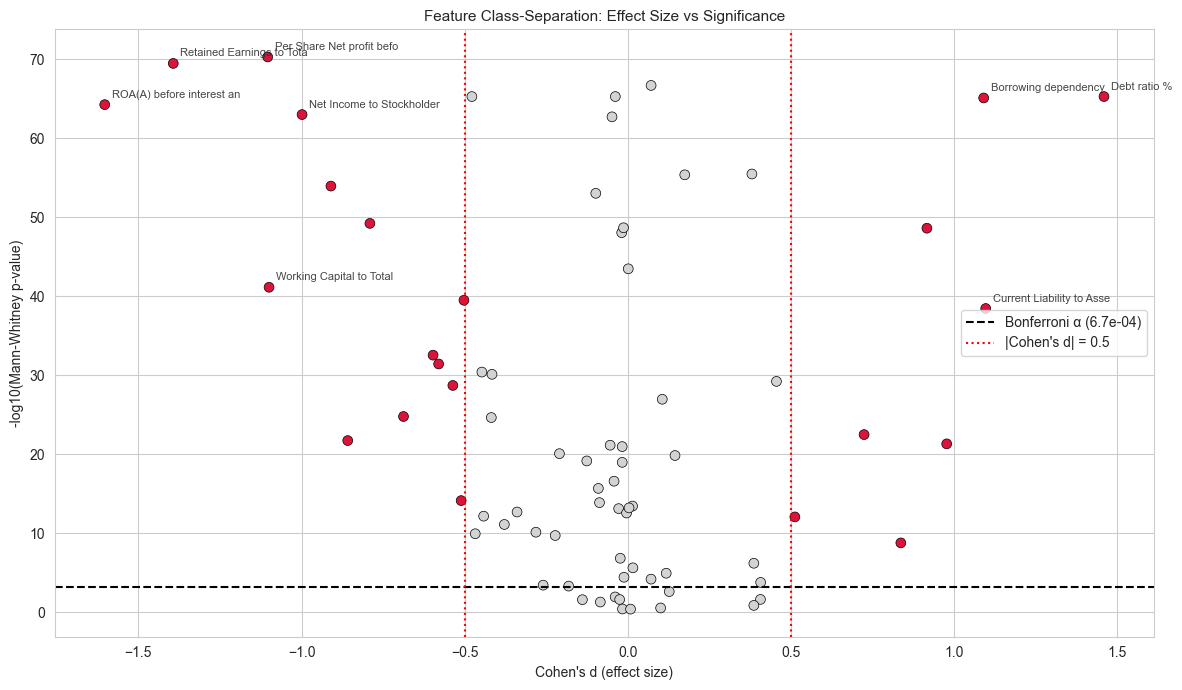

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['crimson' if (abs(d) > 0.5 and p < alpha) else 'lightgray'
          for d, p in zip(class_sep['cohens_d'], class_sep['mw_pvalue'])]

ax.scatter(class_sep['cohens_d'], class_sep['neg_log10_p'],
           c=colors, s=50, edgecolor='black', linewidth=0.5)
ax.axhline(-np.log10(alpha), color='black', linestyle='--',
           label=f'Bonferroni α ({alpha:.1e})')
ax.axvline(0.5, color='red', linestyle=':', label="|Cohen's d| = 0.5")
ax.axvline(-0.5, color='red', linestyle=':')
ax.set_xlabel("Cohen's d (effect size)")
ax.set_ylabel('-log10(Mann-Whitney p-value)')
ax.set_title('Feature Class-Separation: Effect Size vs Significance')
ax.legend()

# Label the top 8 most discriminative
for feat in class_sep.head(8).index:
    ax.annotate(feat[:25], (class_sep.loc[feat, 'cohens_d'],
                             class_sep.loc[feat, 'neg_log10_p']),
                fontsize=8, alpha=0.85,
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## G. Mutual Information Ranking

In [18]:
# MI is sensitive to scale, so clip extreme values first for this analysis only
X_clipped = X_pruned.copy()
for col in X_clipped.columns:
    q99 = X_clipped[col].quantile(0.99)
    q01 = X_clipped[col].quantile(0.01)
    X_clipped[col] = X_clipped[col].clip(q01, q99)

mi_scores = mutual_info_classif(X_clipped, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': X_clipped.columns, 'MI': mi_scores})
mi_df = mi_df.sort_values('MI', ascending=False).reset_index(drop=True)

print("TOP 20 FEATURES BY MUTUAL INFORMATION WITH TARGET\n")
print(mi_df.head(20).round(4).to_string(index=False))

TOP 20 FEATURES BY MUTUAL INFORMATION WITH TARGET

                                           feature     MI
                Net Income to Stockholder's Equity 0.0428
            ROA(A) before interest and % after tax 0.0390
                        Total debt/Total net worth 0.0384
                               Equity to Liability 0.0377
                                      Debt ratio % 0.0371
                              Borrowing dependency 0.0366
          Per Share Net profit before tax (Yuan ¥) 0.0362
Interest Coverage Ratio (Interest expense to EBIT) 0.0340
                            Interest Expense Ratio 0.0339
                Degree of Financial Leverage (DFL) 0.0335
                 Retained Earnings to Total Assets 0.0334
                             Net Value Growth Rate 0.0326
                           Net Value Per Share (C) 0.0313
                        Total income/Total expense 0.0294
                       After-tax net Interest Rate 0.0288
                     

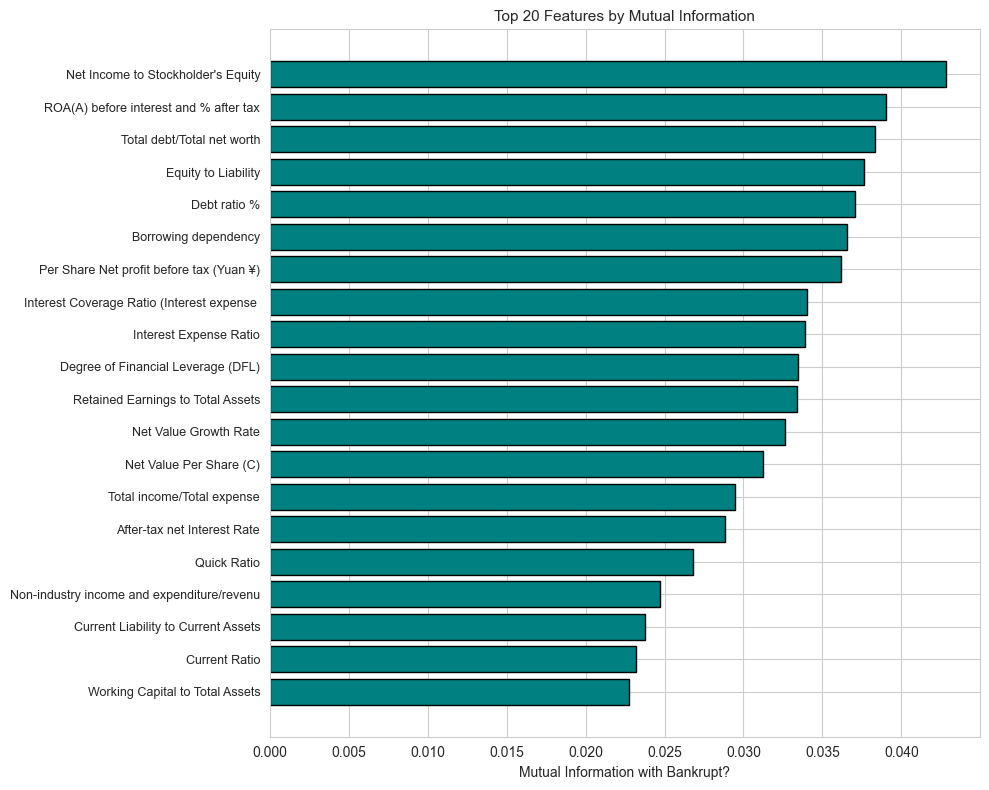

In [19]:
# Visualize top MI features
fig, ax = plt.subplots(figsize=(10, 8))
top20 = mi_df.head(20).iloc[::-1]
ax.barh(range(len(top20)), top20['MI'], color='teal', edgecolor='black')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f[:42] for f in top20['feature']], fontsize=9)
ax.set_xlabel('Mutual Information with Bankrupt?')
ax.set_title('Top 20 Features by Mutual Information')
plt.tight_layout()
plt.show()

## H. Visual Discrimination — Boxplots & Violin Plots

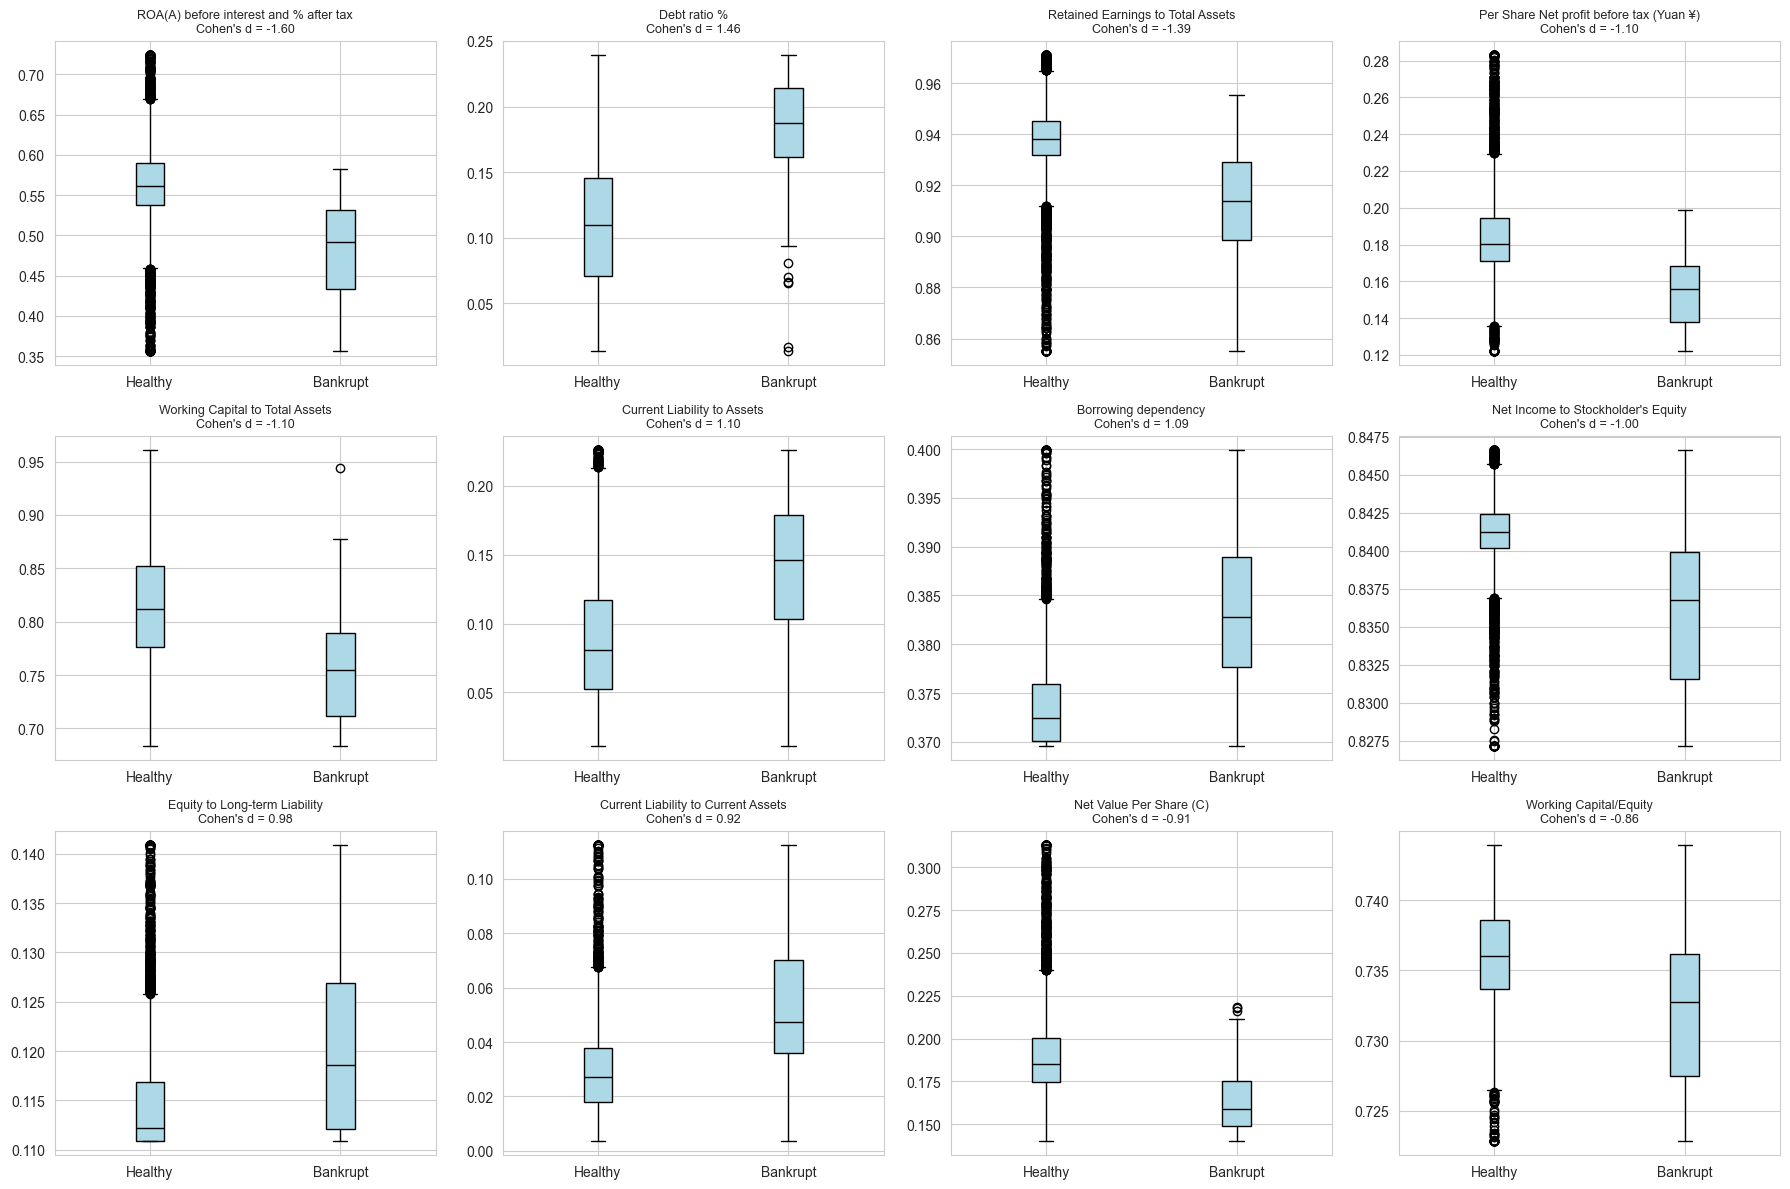

In [20]:
# Top 12 features by Cohen's d, visualized by class
top_features = class_sep.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, feat in enumerate(top_features):
    ax = axes[i // 4, i % 4]
    data0 = X_pruned.loc[y==0, feat]
    data1 = X_pruned.loc[y==1, feat]
    # Use percentile clipping for visibility — outliers destroy the scale otherwise
    lo, hi = np.percentile(pd.concat([data0, data1]), [1, 99])
    data0_c = data0.clip(lo, hi)
    data1_c = data1.clip(lo, hi)
    ax.boxplot([data0_c, data1_c], labels=['Healthy', 'Bankrupt'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='black'))
    d = class_sep.loc[feat, 'cohens_d']
    ax.set_title(f"{feat[:40]}\nCohen's d = {d:.2f}", fontsize=9)

plt.tight_layout()
plt.show()

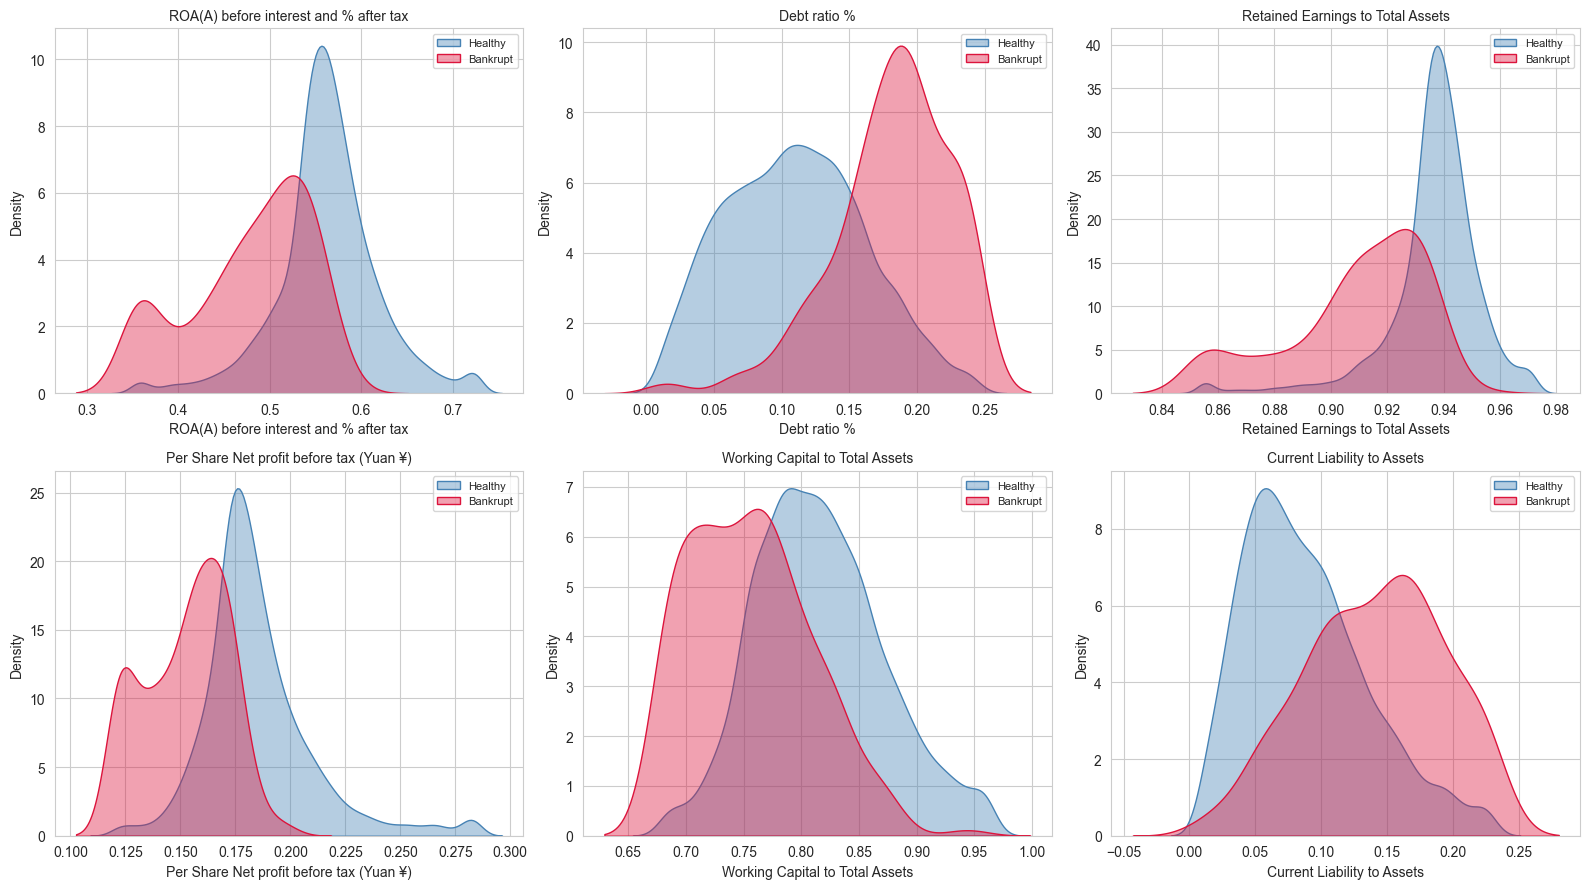

In [21]:
# KDE overlays for the top 6 features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
top_six = class_sep.head(6).index.tolist()

for i, feat in enumerate(top_six):
    ax = axes[i // 3, i % 3]
    data0 = X_pruned.loc[y==0, feat]
    data1 = X_pruned.loc[y==1, feat]
    lo, hi = np.percentile(pd.concat([data0, data1]), [1, 99])
    # Seaborn KDE (density) for smooth comparison
    sns.kdeplot(data0.clip(lo, hi), label='Healthy', ax=ax, color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(data1.clip(lo, hi), label='Bankrupt', ax=ax, color='crimson', fill=True, alpha=0.4)
    ax.set_title(feat[:45], fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

## I. Feature Domain Grouping

In [22]:
# Rough domain groupings based on feature names
domain_groups = {
    'Profitability': ['ROA', 'Net Income', 'Gross Margin', 'Operating Profit', 'Profit',
                      'EPS', 'Per Share', 'Return'],
    'Liquidity':     ['Cash', 'Quick', 'Current Ratio', 'Working Capital', 'Liquidity'],
    'Leverage':      ['Debt', 'Liability', 'Borrowing', 'Equity', 'Net worth'],
    'Efficiency':    ['Turnover', 'Expense Rate', 'Collection', 'Revenue per', 'Asset Turnover'],
    'Growth':        ['Growth Rate', 'Growth'],
    'Size':          ['Total Assets', 'Revenue', 'Capital', 'Total income'],
    'Other':         []
}

def classify(feature_name):
    for group, keywords in domain_groups.items():
        if any(kw.lower() in feature_name.lower() for kw in keywords):
            return group
    return 'Other'

feature_domains = pd.Series({f: classify(f) for f in X_pruned.columns}, name='domain')
print("FEATURES PER DOMAIN\n")
print(feature_domains.value_counts().to_string())

FEATURES PER DOMAIN

domain
Liquidity        17
Leverage         15
Profitability    15
Other            12
Efficiency        9
Size              5
Growth            2


In [23]:
merged = class_sep[['abs_cohens_d']].join(feature_domains)
domain_power = merged.groupby('domain')['abs_cohens_d'].agg(['mean', 'max', 'count'])
domain_power = domain_power.sort_values('mean', ascending=False)
print("PREDICTIVE POWER BY DOMAIN\n")
print(domain_power.round(3).to_string())

PREDICTIVE POWER BY DOMAIN

                mean    max  count
domain                            
Leverage       0.538  1.459     15
Profitability  0.489  1.603     15
Size           0.382  1.393      5
Liquidity      0.346  1.100     17
Growth         0.301  0.380      2
Other          0.284  0.836     12
Efficiency     0.168  0.407      9


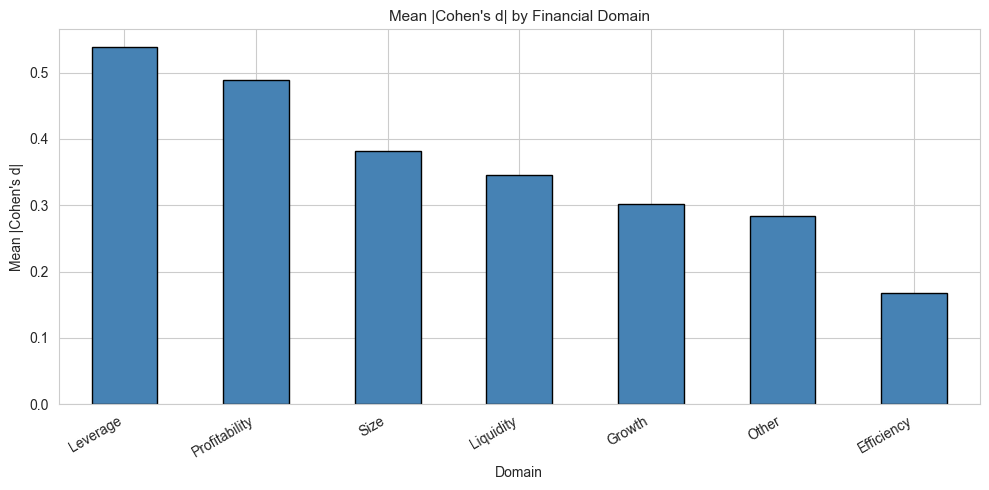

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
domain_power['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Mean |Cohen's d| by Financial Domain")
ax.set_ylabel("Mean |Cohen's d|")
ax.set_xlabel('Domain')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## J. Outlier Analysis

In [25]:
# IQR-based outlier count per feature
q1 = X_pruned.quantile(0.25)
q3 = X_pruned.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = (X_pruned < lower) | (X_pruned > upper)

outlier_per_feature = outlier_mask.sum().sort_values(ascending=False)
print("FEATURES WITH MOST OUTLIERS (IQR rule)\n")
print(outlier_per_feature.head(15).to_string())

FEATURES WITH MOST OUTLIERS (IQR rule)

Degree of Financial Leverage (DFL)                    1274
Fixed Assets Turnover Frequency                       1215
Interest Coverage Ratio (Interest expense to EBIT)    1208
Total Asset Growth Rate                               1188
Current Asset Turnover Rate                           1188
Interest Expense Ratio                                1153
Cash Flow to Liability                                1026
No-credit Interval                                     961
Non-industry income and expenditure/revenue            941
Cash Flow to Sales                                     898
Continuous Net Profit Growth Rate                      893
Regular Net Profit Growth Rate                         886
Operating Profit Growth Rate                           863
Inventory/Working Capital                              814
Contingent liabilities/Net worth                       787


In [26]:
# Outliers per row — identify which companies are extreme on many features
outliers_per_row = outlier_mask.sum(axis=1)
print(f"Rows with > 20 outlier features: {(outliers_per_row > 20).sum()}")
print(f"Rows with > 10 outlier features: {(outliers_per_row > 10).sum()}")
print(f"Rows with 0 outlier features:    {(outliers_per_row == 0).sum()}")

# Do bankrupt rows have more outliers on average?
print(f"\nMean outlier count by class:")
print(f"  Healthy (y=0): {outliers_per_row[y==0].mean():.2f}")
print(f"  Bankrupt (y=1): {outliers_per_row[y==1].mean():.2f}")

Rows with > 20 outlier features: 134
Rows with > 10 outlier features: 1148
Rows with 0 outlier features:    390

Mean outlier count by class:
  Healthy (y=0): 6.29
  Bankrupt (y=1): 12.74


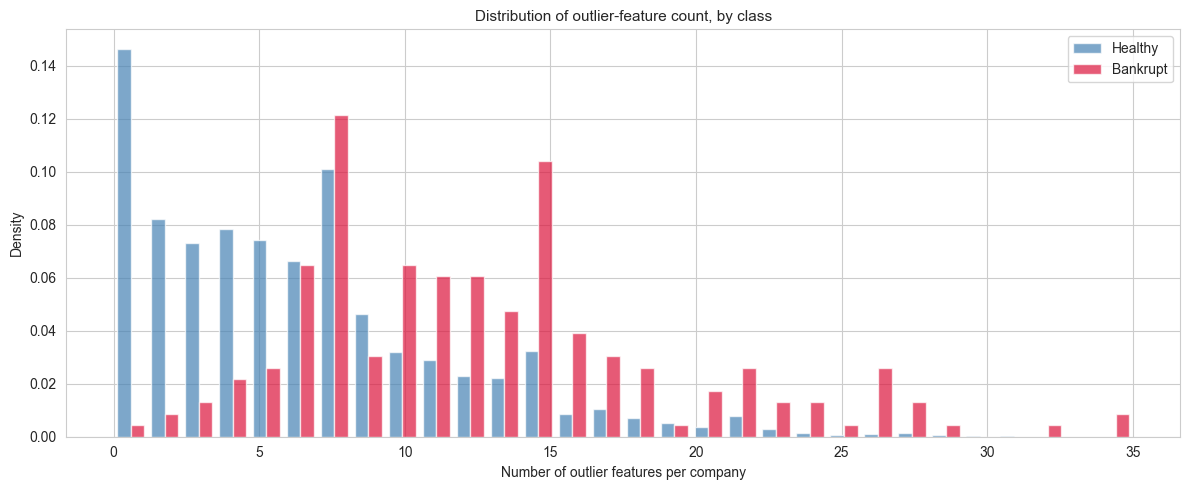

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist([outliers_per_row[y==0], outliers_per_row[y==1]],
        bins=30, label=['Healthy', 'Bankrupt'],
        color=['steelblue', 'crimson'], density=True, alpha=0.7)
ax.set_xlabel('Number of outlier features per company')
ax.set_ylabel('Density')
ax.set_title('Distribution of outlier-feature count, by class')
ax.legend()
plt.tight_layout()
plt.show()

## K. Summary & Handoff Notes

In [28]:
print(f"\nDataset shape:{df.shape[0]} rows × {df.shape[1]} cols")
print(f"Target imbalance:{(y==1).sum()} bankrupt / {len(y)} total ({y.mean()*100:.2f}%)")
print(f"Missing values:{X.isnull().sum().sum()}")
print(f"Zero-variance features:1 (Net Income Flag)")
print(f"\nFeatures after zero-var drop:{X.shape[1]}")
print(f"Features with extreme scale: {len(extreme)} (values up to 10¹⁰)")
print(f"Features heavily skewed (|s|>3):{len(heavy_skew)}")
print(f"Highly correlated pairs (|r|>.95):{(pairs_df['|r|'] > 0.95).sum()}")
print(f"Features to drop (correlation):{len(to_drop)}")
print(f"Features remaining after pruning:{X_pruned.shape[1]}")
print(f"\nStatistically significant features (Bonferroni): {len(significant)} / {X_pruned.shape[1]}")
print(f"Features with |Cohen's d| > 0.5:{(class_sep['abs_cohens_d'] > 0.5).sum()}")
print(f"Features with |Cohen's d| > 0.8:|{(class_sep['abs_cohens_d'] > 0.8).sum()}")


Dataset shape:5807 rows × 97 cols
Target imbalance:198 bankrupt / 5807 total (3.41%)
Missing values:0
Zero-variance features:1 (Net Income Flag)

Features after zero-var drop:94
Features with extreme scale: 24 (values up to 10¹⁰)
Features heavily skewed (|s|>3):66
Highly correlated pairs (|r|>.95):24
Features to drop (correlation):19
Features remaining after pruning:75

Statistically significant features (Bonferroni): 65 / 75
Features with |Cohen's d| > 0.5:22
Features with |Cohen's d| > 0.8:|13


# Preprocessing Pipeline — Scaling + PCA + joblib Save

In [29]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drops specified columns. Used as the first stage of the pipeline so that
    test data goes through the exact same column-drop step as training data."""
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Accept either DataFrame or array-like; keep as DataFrame if possible
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=[c for c in self.columns_to_drop if c in X.columns])
        return X  # if array, nothing to drop by name

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return [f for f in input_features if f not in self.columns_to_drop]


# Collect ALL columns to drop: zero-variance + correlation-redundant
# These were identified during EDA (Sections A and E)
cols_to_drop = list(zero_var_cols) + list(to_drop)
print(f"Total columns the pipeline will drop: {len(cols_to_drop)}")
print(f"  - Zero-variance: {len(zero_var_cols)}")
print(f"  - Correlation-redundant: {len(to_drop)}")

Total columns the pipeline will drop: 20
  - Zero-variance: 1
  - Correlation-redundant: 19


###  the preprocessing pipeline

In [30]:
# Re-create the original feature matrix (with zero-var feature included, so pipeline can drop it)
X_original = df.drop(columns=['Index', 'Bankrupt?'])
print(f"Original feature matrix: {X_original.shape}")
print(f"Pipeline will drop {len(cols_to_drop)} columns, leaving {X_original.shape[1] - len(cols_to_drop)}")

Original feature matrix: (5807, 95)
Pipeline will drop 20 columns, leaving 75


In [31]:
# Build the pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('drop_cols', ColumnDropper(columns_to_drop=cols_to_drop)),
    ('power_transform', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE))  # keep enough comps for 95% variance
])

# Fit on the training data
preprocessing_pipeline.fit(X_original)

# Transform to get the final preprocessed matrix
X_transformed = preprocessing_pipeline.transform(X_original)

print(f"After pipeline transformation:")
print(f"  Original shape: {X_original.shape}")
print(f"  Transformed shape: {X_transformed.shape}")
print(f"  Components explain {preprocessing_pipeline.named_steps['pca'].explained_variance_ratio_.sum()*100:.2f}% of total variance")

After pipeline transformation:
  Original shape: (5807, 95)
  Transformed shape: (5807, 47)
  Components explain 95.27% of total variance


###  Examine PCA output

The number of components came out automatically based on the 95% variance threshold. Let's visualize the explained-variance curve to confirm the choice is sensible and to see whether we could comfortably drop to fewer components.

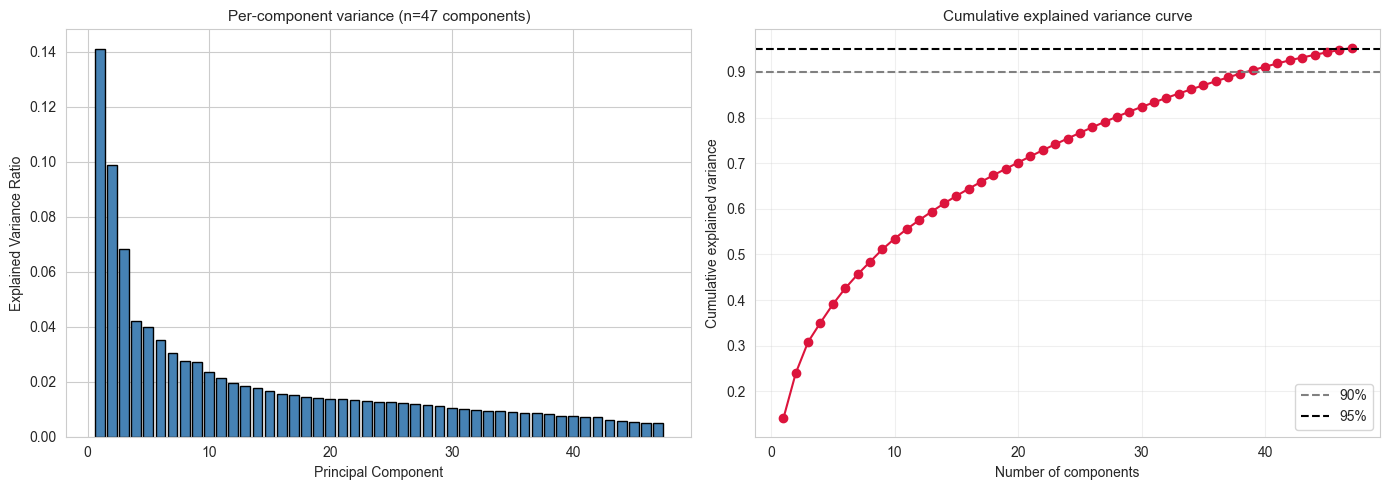

  80% variance needs 28 components
  85% variance needs 33 components
  90% variance needs 39 components
  95% variance needs 47 components


In [32]:
pca = preprocessing_pipeline.named_steps['pca']
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual component contribution
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'Per-component variance (n={len(explained)} components)')

# Right: cumulative curve
axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='crimson')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90%')
axes[1].axhline(0.95, color='black', linestyle='--', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report thresholds
for threshold in [0.80, 0.85, 0.90, 0.95]:
    n = np.searchsorted(cumulative, threshold) + 1
    print(f"  {threshold*100:.0f}% variance needs {n} components")

### Verify spec compliance

1. **Feature count ≤ 50** (Section 3.1 of spec)
2. **No NaN or Inf values** in output
3. **Reproducibility** — transforming the same input twice must give identical output

In [33]:
# Check 1: feature count
n_components = X_transformed.shape[1]
print(f"[✓] Feature count: {n_components} components (spec cap is 50)" if n_components <= 50
      else f"[✗] FAIL — {n_components} components exceeds the 50-feature cap")

# Check 2: NaN / Inf
has_nan = np.isnan(X_transformed).any()
has_inf = np.isinf(X_transformed).any()
print(f"[✓] No NaN/Inf in output" if not (has_nan or has_inf) 
      else f"[✗] FAIL — NaN: {has_nan}, Inf: {has_inf}")

# Check 3: reproducibility
X_transformed_again = preprocessing_pipeline.transform(X_original)
reproducible = np.allclose(X_transformed, X_transformed_again)
print(f"[✓] Reproducible (same input → same output)" if reproducible
      else f"[✗] FAIL — output not reproducible")

# Summary statistics of the transformed output
print(f"\nOutput matrix statistics:")
print(f"  Shape: {X_transformed.shape}")
print(f"  Mean: {X_transformed.mean():.4f} (should be ~0)")
print(f"  Std:  {X_transformed.std():.4f}")
print(f"  Min:  {X_transformed.min():.4f}")
print(f"  Max:  {X_transformed.max():.4f}")

[✓] Feature count: 47 components (spec cap is 50)
[✓] No NaN/Inf in output
[✓] Reproducible (same input → same output)

Output matrix statistics:
  Shape: (5807, 47)
  Mean: 0.0000 (should be ~0)
  Std:  1.2330
  Min:  -56.1045
  Max:  40.7028


In [34]:
# Save the fitted pipeline
pipeline_path = 'preprocessing_pipeline.joblib'
joblib.dump(preprocessing_pipeline, pipeline_path)
print(f"Saved: {pipeline_path}")

# Also save the column list as a sanity check artifact
feature_metadata = {
    'original_columns': X_original.columns.tolist(),
    'dropped_columns': cols_to_drop,
    'n_components': n_components,
    'random_state': RANDOM_STATE
}
joblib.dump(feature_metadata, 'preprocessing_metadata.joblib')
print(f"Saved: preprocessing_metadata.joblib")
loaded_pipeline = joblib.load(pipeline_path)
X_check = loaded_pipeline.transform(X_original)
print(f"\n[✓] Reload test passed: output shape {X_check.shape}")

Saved: preprocessing_pipeline.joblib
Saved: preprocessing_metadata.joblib

[✓] Reload test passed: output shape (5807, 47)


### Store transformed data forclustering)

In [35]:
# Wrap transformed data in a DataFrame with meaningful column names
pc_names = [f'PC{i+1}' for i in range(X_transformed.shape[1])]
X_transformed_df = pd.DataFrame(X_transformed, columns=pc_names, index=X_original.index)

# Keep alongside target and index for Step 4
X_transformed_df.to_csv('X_transformed.csv', index=False)
print(f"Saved transformed matrix: X_transformed.csv ({X_transformed_df.shape})")
# Preview
print(f"\nTransformed data preview:")
print(X_transformed_df.head(3).round(3))

Saved transformed matrix: X_transformed.csv ((5807, 47))

Transformed data preview:
     PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9   PC10  ...  \
0  2.700 -0.896 -0.803 -0.603  0.201 -1.551  2.438 -0.057  0.832  0.064  ...   
1 -0.223  1.489 -0.580  0.047 -0.463 -0.042 -0.902  0.993 -0.079  1.006  ...   
2 -2.141  0.200 -1.397  0.274  0.629  0.110 -0.842 -0.342  0.591  1.313  ...   

    PC38   PC39   PC40   PC41   PC42   PC43   PC44   PC45   PC46   PC47  
0 -0.146  0.227 -0.087  0.047 -0.659 -0.792 -0.110  0.329  0.186  0.018  
1 -0.039 -0.340 -0.038 -0.063 -0.066  0.388 -0.730 -0.203  0.371 -0.009  
2  0.143 -0.490 -0.306 -0.075 -0.863  0.206 -0.211  0.480  0.080 -0.025  

[3 rows x 47 columns]


###  Clustering — KMeans with k=8

### Clustering imports

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Clustering imports loaded")

Clustering imports loaded


### Fit KMeans with k=8

In [37]:
K = 8  # team decision 
kmeans = KMeans(
    n_clusters=K,
    n_init=20,            # 20 random restarts, keep best
    max_iter=500,
    random_state=42
)
cluster_labels = kmeans.fit_predict(X_transformed)

print(f"KMeans fit complete")
print(f"Number of clusters: {K}")
print(f"Inertia (within-cluster SSE): {kmeans.inertia_:.1f}")
print(f"Iterations to converge: {kmeans.n_iter_}")

KMeans fit complete
Number of clusters: 8
Inertia (within-cluster SSE): 306805.4
Iterations to converge: 34


###  Cluster composition table

The single most important output of this step: how many companies and how many bankruptcies landed in each cluster. This feeds directly into Table 3 of the final report (spec Section 6.2).

In [38]:
# Build cluster composition dataframe
composition = pd.DataFrame({
    'cluster_id':   range(K),
    'n_companies':  [(cluster_labels == c).sum() for c in range(K)],
    'n_bankrupt':   [((cluster_labels == c) & (y == 1)).sum() for c in range(K)],
    'n_healthy':    [((cluster_labels == c) & (y == 0)).sum() for c in range(K)],
})
composition['bankrupt_pct'] = (composition['n_bankrupt'] / composition['n_companies'] * 100).round(2)
composition = composition.sort_values('bankrupt_pct', ascending=False).reset_index(drop=True)

print("CLUSTER COMPOSITION (sorted by bankruptcy %)\n")
print(composition.to_string(index=False))
print(f"\nTotal companies: {composition['n_companies'].sum()}  (should be 5807)")
print(f"Total bankruptcies: {composition['n_bankrupt'].sum()}  (should be 198)")

CLUSTER COMPOSITION (sorted by bankruptcy %)

 cluster_id  n_companies  n_bankrupt  n_healthy  bankrupt_pct
          6            7           5          2         71.43
          2          904         101        803         11.17
          5          916          72        844          7.86
          4           33           2         31          6.06
          0          610           4        606          0.66
          3         1024           6       1018          0.59
          1         1749           8       1741          0.46
          7          564           0        564          0.00

Total companies: 5807  (should be 5807)
Total bankruptcies: 198  (should be 198)


### Detect constant-prediction clusters

In [39]:
all_healthy  = composition[composition['n_bankrupt'] == 0]
all_bankrupt = composition[composition['n_healthy'] == 0]
mixed        = composition[(composition['n_bankrupt'] > 0) & (composition['n_healthy'] > 0)]

print(f"Clusters that are 100% healthy   (const predictor ĥ=0): {len(all_healthy)}")
print(f"Clusters that are 100% bankrupt  (const predictor ĥ=1): {len(all_bankrupt)}")
print(f"Mixed clusters needing a real model: {len(mixed)}")

if len(all_healthy) > 0:
    print(f"\nAll-healthy cluster IDs: {all_healthy['cluster_id'].tolist()}")
if len(all_bankrupt) > 0:
    print(f"All-bankrupt cluster IDs: {all_bankrupt['cluster_id'].tolist()}")

# Team-size sanity check
team_size = 4   # update if your team size differs
if len(mixed) < team_size:
    print(f"\n[!] WARNING: only {len(mixed)} mixed clusters for a {team_size}-person team.")
    print(f"    Spec says to increment k and retry until each member has at least one cluster.")
else:
    print(f"\n[OK] {len(mixed)} mixed clusters available for {team_size} team members.")

Clusters that are 100% healthy   (const predictor ĥ=0): 1
Clusters that are 100% bankrupt  (const predictor ĥ=1): 0
Mixed clusters needing a real model: 7

All-healthy cluster IDs: [7]

[OK] 7 mixed clusters available for 4 team members.


### Visualize cluster sizes and bankruptcy rates

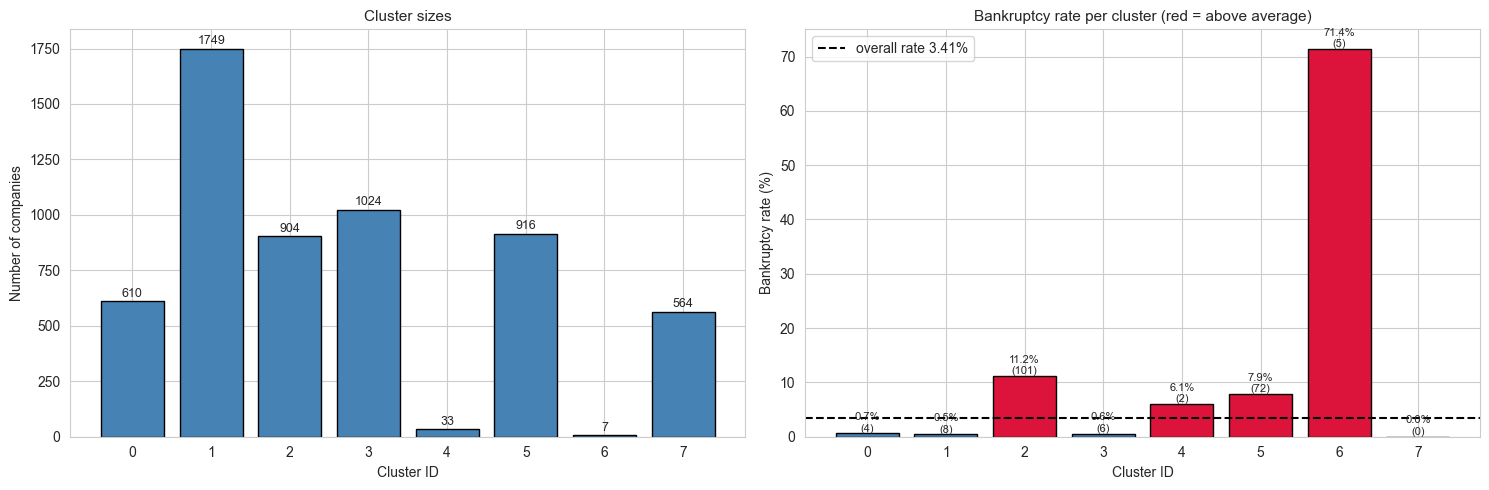

In [40]:
# Re-sort by cluster_id for plotting
comp_by_id = composition.sort_values('cluster_id').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: cluster sizes
bars = axes[0].bar(comp_by_id['cluster_id'], comp_by_id['n_companies'],
                    color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of companies')
axes[0].set_title('Cluster sizes')
for bar, v in zip(bars, comp_by_id['n_companies']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20, str(v),
                 ha='center', fontsize=9)

# Right: bankruptcy percentage per cluster
colors = ['crimson' if p > 3.41 else 'steelblue' for p in comp_by_id['bankrupt_pct']]
bars = axes[1].bar(comp_by_id['cluster_id'], comp_by_id['bankrupt_pct'],
                    color=colors, edgecolor='black')
axes[1].axhline(3.41, color='black', linestyle='--', label='overall rate 3.41%')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Bankruptcy rate (%)')
axes[1].set_title('Bankruptcy rate per cluster (red = above average)')
axes[1].legend()
for bar, v, n in zip(bars, comp_by_id['bankrupt_pct'], comp_by_id['n_bankrupt']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%\n({n})',
                 ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 2D cluster visualization (PC1 vs PC2)


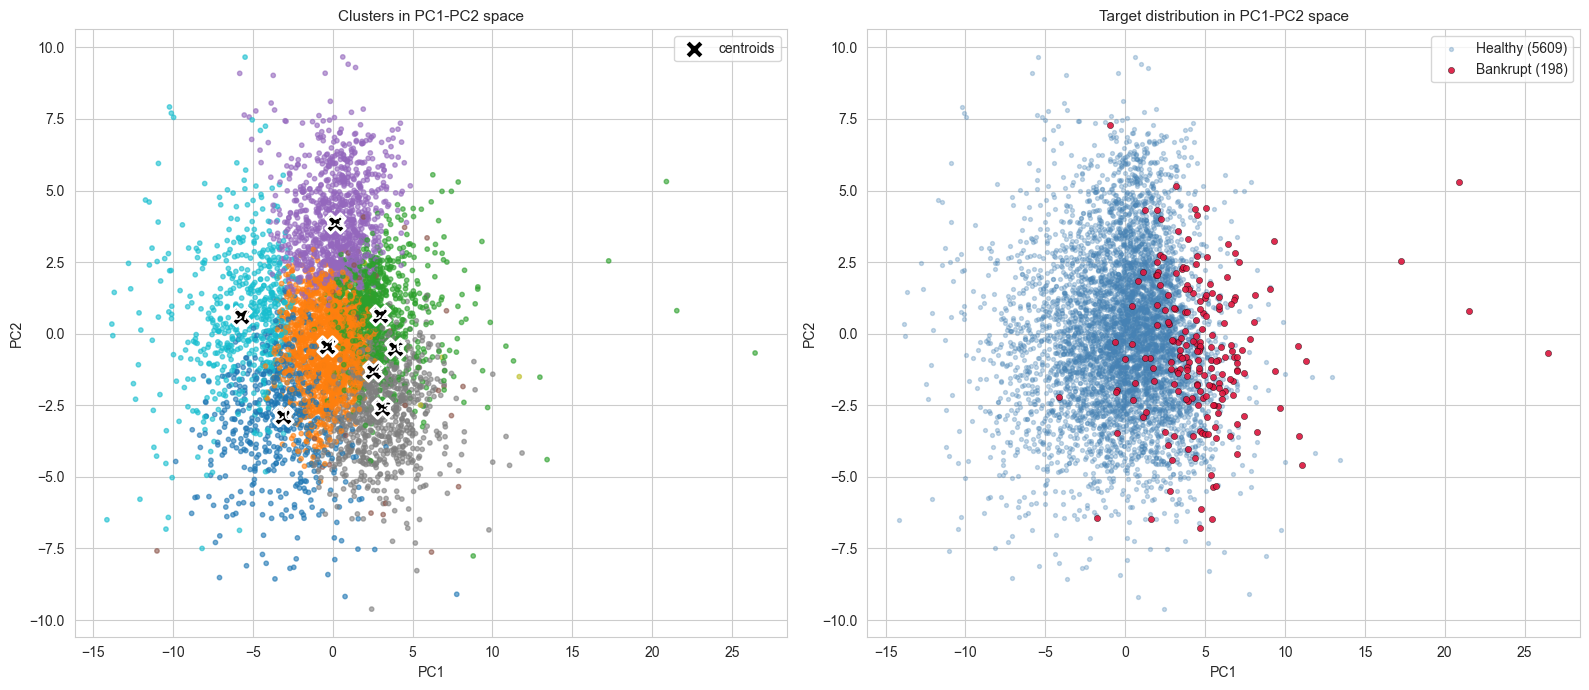

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by cluster
scatter = axes[0].scatter(X_transformed[:, 0], X_transformed[:, 1],
                           c=cluster_labels, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Clusters in PC1-PC2 space')
# Plot centroids
centroids_2d = kmeans.cluster_centers_[:, :2]
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=200, edgecolor='white', linewidth=2,
                label='centroids')
for i, (x, z) in enumerate(centroids_2d):
    axes[0].annotate(f'C{i}', (x, z), fontsize=11, fontweight='bold',
                     color='white', ha='center', va='center')
axes[0].legend()

# Right: healthy vs bankrupt overlay
healthy_mask  = y == 0
bankrupt_mask = y == 1
axes[1].scatter(X_transformed[healthy_mask, 0], X_transformed[healthy_mask, 1],
                c='steelblue', s=8, alpha=0.3, label=f'Healthy ({healthy_mask.sum()})')
axes[1].scatter(X_transformed[bankrupt_mask, 0], X_transformed[bankrupt_mask, 1],
                c='crimson', s=20, alpha=0.9, label=f'Bankrupt ({bankrupt_mask.sum()})',
                edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Target distribution in PC1-PC2 space')
axes[1].legend()

plt.tight_layout()
plt.show()

###  Silhouette score (cluster quality metric)

Silhouette score ranges from −1 to +1. Values near +1 mean clusters are well-separated; values near 0 mean clusters overlap; negative values mean points are likely in the wrong cluster. For high-dimensional messy real-world data like ours, anything above 0.1 is typically acceptable; above 0.25 is good.

In [42]:
# Silhouette on a random subsample for speed (full 5807 × 47 works too but slower)
from sklearn.utils import resample

sample_idx = resample(np.arange(len(cluster_labels)),
                      n_samples=min(2000, len(cluster_labels)),
                      replace=False, random_state=RANDOM_STATE)

sil_score = silhouette_score(X_transformed[sample_idx],
                              cluster_labels[sample_idx],
                              random_state=RANDOM_STATE)
print(f"Silhouette score (sample of 2000): {sil_score:.3f}")

if sil_score > 0.25:
    print("  → Good cluster separation")
elif sil_score > 0.10:
    print("  → Acceptable cluster separation for high-dimensional real-world data")
else:
    print("  → Weak separation — clusters overlap heavily; consider different k or method")

Silhouette score (sample of 2000): 0.065
  → Weak separation — clusters overlap heavily; consider different k or method


###  Characterize each cluster in financial terms


For each cluster, compute the mean of every **original** (non-PCA) feature. Then compare that mean to the overall population mean to identify distinguishing features. This gives us human-readable cluster profiles.

In [43]:
# Attach cluster labels to the original (pre-PCA, post-correlation-prune) features
X_with_clusters = X_pruned.copy()
X_with_clusters['cluster'] = cluster_labels
X_with_clusters['bankrupt'] = y.values

# Per-cluster means of original features, compared to overall mean
overall_means = X_pruned.mean()
cluster_means = X_with_clusters.groupby('cluster')[X_pruned.columns].mean()

# Z-score each cluster mean relative to the population (standardized deviation)
overall_stds = X_pruned.std().replace(0, 1)  # avoid division by zero
cluster_zscores = (cluster_means - overall_means) / overall_stds

print("Top 5 distinguishing features per cluster (by absolute z-score from population mean):\n")
for c in range(K):
    n = (cluster_labels == c).sum()
    n_bk = ((cluster_labels == c) & (y == 1)).sum()
    pct = n_bk / n * 100
    top_features = cluster_zscores.loc[c].abs().sort_values(ascending=False).head(5)
    print(f"\n{'='*70}")
    print(f"CLUSTER {c}  |  n={n}  bankrupt={n_bk} ({pct:.1f}%)")
    print(f"{'='*70}")
    for feat in top_features.index:
        z = cluster_zscores.loc[c, feat]
        direction = "ABOVE" if z > 0 else "BELOW"
        print(f"  {feat[:55]:<55} {direction} avg by {abs(z):.2f} std")

Top 5 distinguishing features per cluster (by absolute z-score from population mean):


CLUSTER 0  |  n=610  bankrupt=4 (0.7%)
  Equity to Liability                                     ABOVE avg by 1.32 std
  Debt ratio %                                            BELOW avg by 1.22 std
  Working Capital to Total Assets                         ABOVE avg by 1.14 std
  Current Liability to Assets                             BELOW avg by 1.00 std
  Cash/Total Assets                                       ABOVE avg by 0.83 std

CLUSTER 1  |  n=1749  bankrupt=8 (0.5%)
  Current Assets/Total Assets                             BELOW avg by 0.40 std
  Current Liability to Assets                             BELOW avg by 0.38 std
  Debt ratio %                                            BELOW avg by 0.33 std
  Retained Earnings to Total Assets                       ABOVE avg by 0.33 std
  Quick Assets/Total Assets                               BELOW avg by 0.32 std

CLUSTER 2  |  n=904  bankrupt=1

### Step 4.9 — Heatmap of cluster profiles

Visualize the z-score matrix as a heatmap restricted to the most informative features, so each teammate can quickly see how their cluster differs from the population.

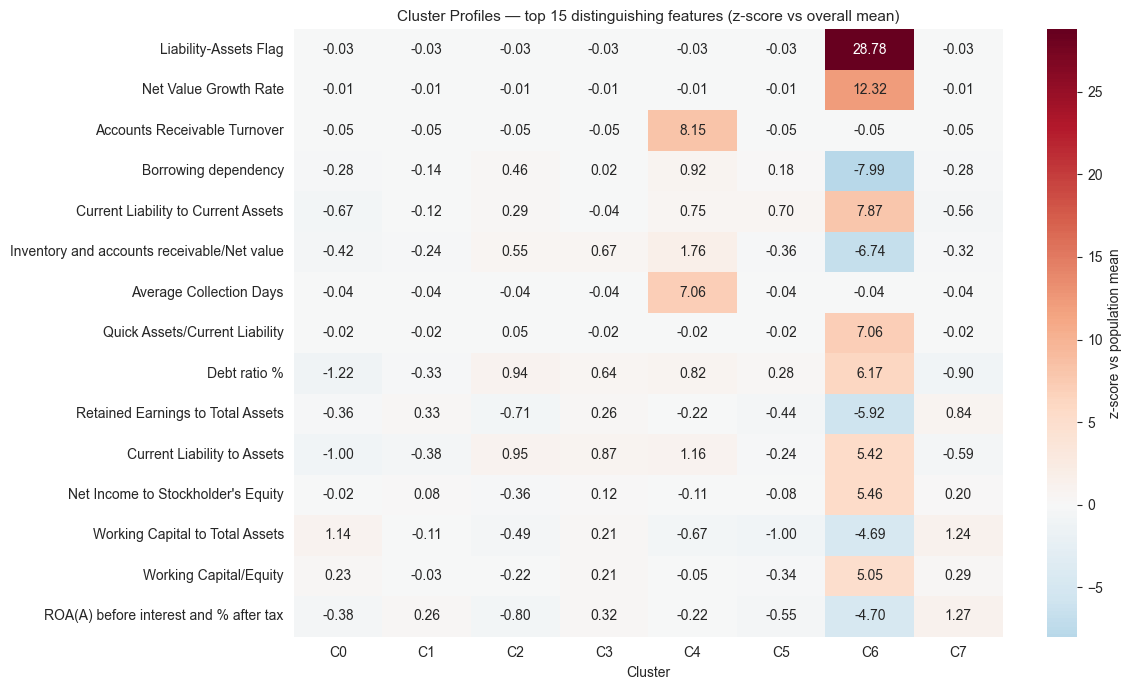

In [44]:
# Find the 15 features with highest between-cluster variance in z-scores
feature_discriminating_power = cluster_zscores.var(axis=0).sort_values(ascending=False)
top_discriminating = feature_discriminating_power.head(15).index.tolist()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cluster_zscores[top_discriminating].T,
            cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'z-score vs population mean'}, ax=ax,
            xticklabels=[f'C{i}' for i in range(K)],
            yticklabels=[f[:45] for f in top_discriminating])
ax.set_title('Cluster Profiles — top 15 distinguishing features (z-score vs overall mean)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

**How to read this heatmap.** Each column is a cluster. Each row is a feature. Red cells mean that cluster has higher-than-average values for that feature; blue cells mean lower-than-average. The magnitude (darkness) shows how many standard deviations away from the population mean.

This is the table to paste into your report when describing each cluster. For example: "Cluster 3 is characterized by above-average debt ratios and below-average profitability — a classic distressed-firm profile, consistent with its elevated bankruptcy rate.

###  Save the KMeans model and cluster assignments

Save with joblib so the generalization notebook can load the model to cluster test data. 

In [45]:
# Save the fitted KMeans model
joblib.dump(kmeans, 'kmeans_model.joblib')
print(f"Saved: kmeans_model.joblib")

# Save cluster assignments as CSV (company index → cluster ID → bankrupt status)
assignments = pd.DataFrame({
    'Index': idx,
    'cluster': cluster_labels,
    'Bankrupt?': y.values
})
assignments.to_csv('cluster_assignments.csv', index=False)
print(f"Saved: cluster_assignments.csv ({assignments.shape})")

# Verify we can reload and use the KMeans model
loaded_kmeans = joblib.load('kmeans_model.joblib')
labels_reloaded = loaded_kmeans.predict(X_transformed)
reproducible = np.array_equal(labels_reloaded, cluster_labels)
print(f"\n[✓] Reload test passed: assignments match" if reproducible 
      else "[✗] FAIL — reload produces different assignments")

print(f"\nPreview of cluster_assignments.csv:")
print(assignments.head(5).to_string(index=False))

Saved: kmeans_model.joblib
Saved: cluster_assignments.csv ((5807, 3))

[✓] Reload test passed: assignments match

Preview of cluster_assignments.csv:
 Index  cluster  Bankrupt?
     0        5          0
     1        1          0
     2        1          0
     3        2          0
     4        3          0


### Step 5.5 — Logistic Regression + pick the winner

Compare RF with a Logistic Regression baseline. LR needs scaled features since it's sensitive to scale (trees don't care).

**Why this isn't just a formality:** KMeans draws approximately-linear cluster boundaries in PCA space. A linear classifier on the same-style representation might actually match those boundaries better than trees. We'll pick whichever model wins on validation accuracy.


### Step 5.1 — Classifier imports

In [46]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)

print("Classifier imports loaded")

Classifier imports loaded


### Step 5.2 — Prepare data

Input: 94 raw features (after zero-variance drop). Target: cluster labels from KMeans (values 0-7).

Why raw features instead of PCA? Two reasons. First, tree-based classifiers handle scale and skew natively, so the PowerTransformer step isn't needed. Second, raw-feature importances are interpretable — we can say "Debt ratio matters most for routing" rather than "PC7 matters most," which satisfies the spec's requirement to identify important features.

In [47]:
X_for_classifier = X.copy()    # 94 original features from EDA
y_cluster = cluster_labels     # 8-class target from KMeans

print(f"Input shape:  {X_for_classifier.shape}")
print(f"Target shape: {y_cluster.shape}")
print(f"\nCluster distribution:")
unique, counts = np.unique(y_cluster, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c:>4} companies ({c/len(y_cluster)*100:5.2f}%)")

Input shape:  (5807, 94)
Target shape: (5807,)

Cluster distribution:
  Cluster 0:  610 companies (10.50%)
  Cluster 1: 1749 companies (30.12%)
  Cluster 2:  904 companies (15.57%)
  Cluster 3: 1024 companies (17.63%)
  Cluster 4:   33 companies ( 0.57%)
  Cluster 5:  916 companies (15.77%)
  Cluster 6:    7 companies ( 0.12%)
  Cluster 7:  564 companies ( 9.71%)


### Step 5.3 — Stratified train/validation split

Stratified so each cluster is proportionally represented in both sets. Especially important because cluster 6 has only 7 companies — without stratification, one split might have zero cluster-6 examples.

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
    X_for_classifier, y_cluster,
    test_size=0.2,
    stratify=y_cluster,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}   Val: {X_val.shape}")
print(f"\nTrain cluster counts: {np.bincount(y_train)}")
print(f"Val   cluster counts: {np.bincount(y_val)}")

Train: (4645, 94)   Val: (1162, 94)

Train cluster counts: [ 488 1399  723  819   26  733    6  451]
Val   cluster counts: [122 350 181 205   7 183   1 113]


### Step 5.4 — Train Random Forest (primary model)

Random Forest is the strong default for tabular classification: it handles feature interactions automatically, needs no scaling, provides interpretable importances, and is robust to the outliers in this dataset. We configure it with 300 trees and mild regularization (min_samples_split=5, min_samples_leaf=2) to avoid memorization.

In [49]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
rf_val_acc = rf.score(X_val, y_val)
print(f"Random Forest validation accuracy: {rf_val_acc:.4f}")

Random Forest validation accuracy: 0.8838


###  Logistic Regression + pick the winner



In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

lr = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
lr_val_acc = lr.score(X_val_scaled, y_val)

print(f"Random Forest val accuracy:       {rf_val_acc:.4f}")
print(f"Logistic Regression val accuracy: {lr_val_acc:.4f}")
print(f"Gap: {(rf_val_acc - lr_val_acc)*100:+.2f} pp  (positive = RF better)")

# Pick winner on validation accuracy
if lr_val_acc > rf_val_acc:
    best_model_name = 'LogisticRegression'
    best_model = lr
    best_val_acc = lr_val_acc
    val_preds = best_model.predict(X_val_scaled)
    print(f"\n>>> Winner: Logistic Regression ({best_val_acc:.4f})")
    print("    KMeans produces approximately-linear cluster boundaries, which a")
    print("    scaled linear model captures cleanly. Trees have to reconstruct")
    print("    those boundaries via many axis-aligned splits, which is harder.")
else:
    best_model_name = 'RandomForest'
    best_model = rf
    best_val_acc = rf_val_acc
    val_preds = best_model.predict(X_val)
    print(f"\n>>> Winner: Random Forest ({best_val_acc:.4f})")


Random Forest val accuracy:       0.8838
Logistic Regression val accuracy: 0.9303
Gap: -4.65 pp  (positive = RF better)

>>> Winner: Logistic Regression (0.9303)
    KMeans produces approximately-linear cluster boundaries, which a
    scaled linear model captures cleanly. Trees have to reconstruct
    those boundaries via many axis-aligned splits, which is harder.


### 5-fold cross-validation on the winning model

Single-split accuracy can be noisy. CV averages across 5 different train/val splits for a more stable estimate.


In [51]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if best_model_name == 'LogisticRegression':
    # LR needs scaling for fair CV — use a Pipeline
    from sklearn.pipeline import make_pipeline
    cv_model = make_pipeline(StandardScaler(),
                              LogisticRegression(max_iter=2000, solver='lbfgs',
                                                  random_state=RANDOM_STATE))
else:
    cv_model = RandomForestClassifier(n_estimators=300, min_samples_split=5,
                                       min_samples_leaf=2, n_jobs=-1,
                                       random_state=RANDOM_STATE)

cv_scores = cross_val_score(cv_model, X_for_classifier, y_cluster,
                             cv=cv, scoring='accuracy', n_jobs=-1)

print(f"{best_model_name} CV accuracy: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")
print(f"Per-fold scores: {[f'{s:.4f}' for s in cv_scores]}")


LogisticRegression CV accuracy: 0.9201 ± 0.0089
Per-fold scores: ['0.9355', '0.9174', '0.9078', '0.9208', '0.9190']


### Per-cluster performance report

Overall accuracy hides per-class behavior. A 90% overall score could still mean cluster 6 is completely misrouted.

In [52]:
print(f"Showing per-cluster performance for: {best_model_name}\n")
print("PER-CLUSTER PERFORMANCE (validation set):\n")
print(classification_report(y_val, val_preds, digits=4, zero_division=0,
                             target_names=[f'Cluster {c}' for c in range(K)]))


Showing per-cluster performance for: LogisticRegression

PER-CLUSTER PERFORMANCE (validation set):

              precision    recall  f1-score   support

   Cluster 0     0.9435    0.9590    0.9512       122
   Cluster 1     0.9413    0.9171    0.9291       350
   Cluster 2     0.9071    0.9171    0.9121       181
   Cluster 3     0.9019    0.9415    0.9212       205
   Cluster 4     0.8000    0.5714    0.6667         7
   Cluster 5     0.9278    0.9126    0.9201       183
   Cluster 6     1.0000    1.0000    1.0000         1
   Cluster 7     0.9825    0.9912    0.9868       113

    accuracy                         0.9303      1162
   macro avg     0.9255    0.9012    0.9109      1162
weighted avg     0.9303    0.9303    0.9301      1162



### Confusion matrix

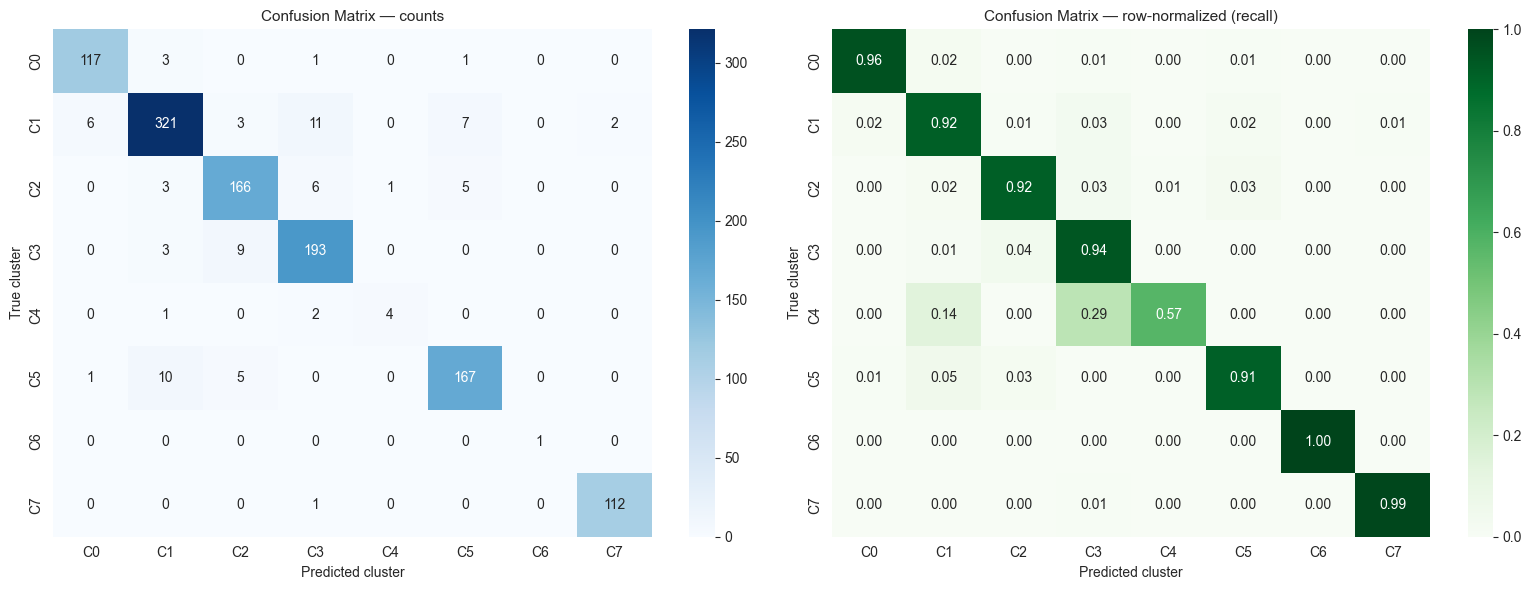

In [53]:
cm = confusion_matrix(y_val, val_preds, labels=list(range(K)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'C{i}' for i in range(K)],
            yticklabels=[f'C{i}' for i in range(K)])
axes[0].set_title('Confusion Matrix — counts')
axes[0].set_xlabel('Predicted cluster')
axes[0].set_ylabel('True cluster')

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=[f'C{i}' for i in range(K)],
            yticklabels=[f'C{i}' for i in range(K)])
axes[1].set_title('Confusion Matrix — row-normalized (recall)')
axes[1].set_xlabel('Predicted cluster')
axes[1].set_ylabel('True cluster')

plt.tight_layout()
plt.show()

### Feature importances

Per spec Section 3.3.1: *"Identify the features that play important roles in this prediction."* These are the financial dimensions along which the 8 clusters most differ.

TOP 20 MOST IMPORTANT FEATURES FOR CLUSTER ROUTING (LogisticRegression)

                                 feature  importance
                           Current Ratio      1.4062
                    Total Asset Turnover      1.2145
               Quick Assets/Total Assets      1.0967
             Current Liability to Assets      0.8607
         Working Capital to Total Assets      0.8535
                            Debt ratio %      0.8248
                        Net worth/Assets      0.8248
                       Cash/Total Assets      0.8208
       Retained Earnings to Total Assets      0.8196
    Long-term fund suitability ratio (A)      0.7485
         Net Worth Turnover Rate (times)      0.7392
     Current Liability to Current Assets      0.6710
              Net Income to Total Assets      0.6607
Per Share Net profit before tax (Yuan ¥)      0.5756
  ROA(A) before interest and % after tax      0.5722
                     Equity to Liability      0.5609
                     Cash 

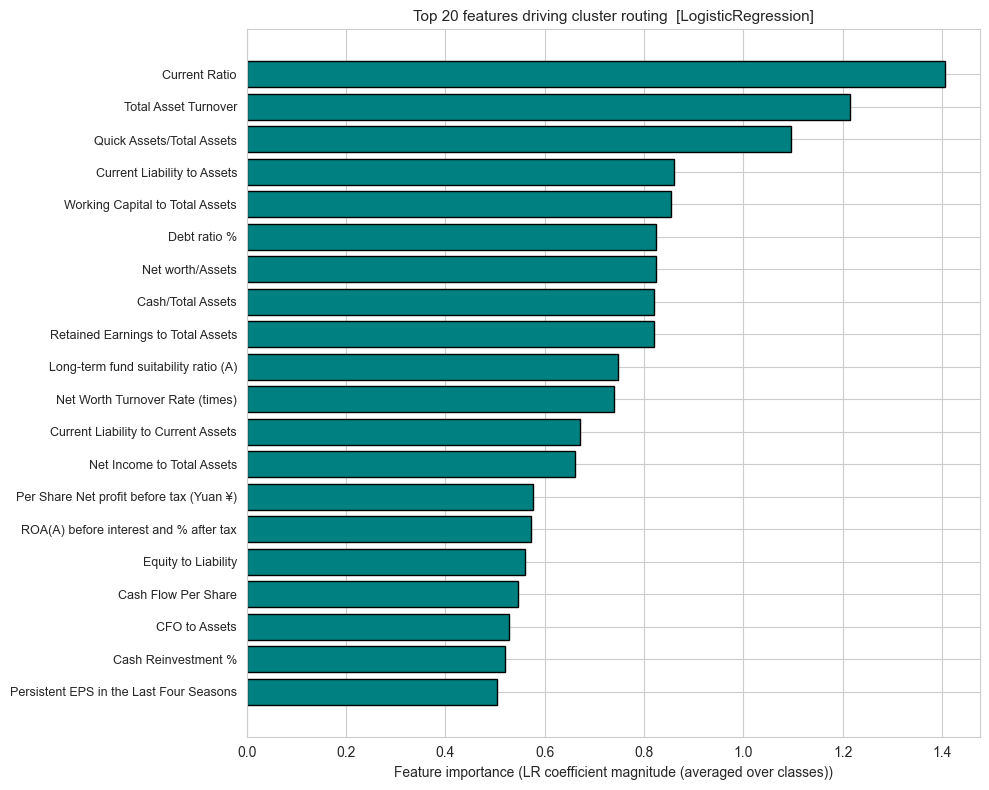

In [54]:
if best_model_name == 'LogisticRegression':
    # LR has per-class coefficients; aggregate to one score per feature by
    # averaging absolute values across classes
    abs_coefs = np.abs(best_model.coef_)  # shape (n_classes, n_features)
    importances = pd.DataFrame({
        'feature': X_for_classifier.columns,
        'importance': abs_coefs.mean(axis=0)
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    imp_label = 'LR coefficient magnitude (averaged over classes)'
else:
    importances = pd.DataFrame({
        'feature': X_for_classifier.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    imp_label = 'gini importance'

print(f"TOP 20 MOST IMPORTANT FEATURES FOR CLUSTER ROUTING ({best_model_name})\n")
print(importances.head(20).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20).iloc[::-1]
ax.barh(range(len(top20)), top20['importance'],
        color='teal', edgecolor='black')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f[:42] for f in top20['feature']], fontsize=9)
ax.set_xlabel(f'Feature importance ({imp_label})')
ax.set_title(f'Top 20 features driving cluster routing  [{best_model_name}]')
plt.tight_layout()
plt.show()


### Routing-error impact by cluster

Not all routing errors are equally bad. Misrouting a hot-cluster company (C2, C5, or C6) is more expensive because the receiving model sees different bankruptcy patterns.

In [55]:
errors_by_cluster = pd.DataFrame({
    'true_cluster':    [f'C{c}' for c in range(K)],
    'n_val_samples':   [(y_val == c).sum() for c in range(K)],
    'n_misrouted':     [((y_val == c) & (val_preds != c)).sum() for c in range(K)],
    'is_hot_cluster':  [c in [2, 5, 6] for c in range(K)],
})
errors_by_cluster['recall_pct'] = (
    (errors_by_cluster['n_val_samples'] - errors_by_cluster['n_misrouted'])
    / errors_by_cluster['n_val_samples'].replace(0, 1) * 100
).round(2)

print("ROUTING PERFORMANCE BY TRUE CLUSTER:\n")
print(errors_by_cluster.to_string(index=False))

hot_mask = np.isin(y_val, [2, 5, 6])
hot_acc = accuracy_score(y_val[hot_mask], val_preds[hot_mask]) if hot_mask.any() else 0
print(f"\nOverall routing accuracy:      {accuracy_score(y_val, val_preds)*100:.2f}%")
print(f"Hot-cluster (C2/C5/C6) recall: {hot_acc*100:.2f}%")

ROUTING PERFORMANCE BY TRUE CLUSTER:

true_cluster  n_val_samples  n_misrouted  is_hot_cluster  recall_pct
          C0            122            5           False       95.90
          C1            350           29           False       91.71
          C2            181           15            True       91.71
          C3            205           12           False       94.15
          C4              7            3           False       57.14
          C5            183           16            True       91.26
          C6              1            0            True      100.00
          C7            113            1           False       99.12

Overall routing accuracy:      93.03%
Hot-cluster (C2/C5/C6) recall: 91.51%


### Refit on full training set and save

Now refit on all 5807 rows (not just the 80% train split) to maximize the data available to the final model.

In [56]:
# Refit the winning model on ALL training data (not just the 80% train split)
if best_model_name == 'LogisticRegression':
    from sklearn.pipeline import Pipeline as SKPipeline
    final_classifier = SKPipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, solver='lbfgs',
                                    random_state=RANDOM_STATE))
    ])
else:
    final_classifier = RandomForestClassifier(
        n_estimators=300, min_samples_split=5, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE
    )

final_classifier.fit(X_for_classifier, y_cluster)
train_acc = final_classifier.score(X_for_classifier, y_cluster)
print(f"Final {best_model_name} training accuracy: {train_acc:.4f}")

joblib.dump(final_classifier, 'cluster_id_classifier.joblib')
print(f"Saved: cluster_id_classifier.joblib")

# Reload test
loaded = joblib.load('cluster_id_classifier.joblib')
ok = np.array_equal(loaded.predict(X_for_classifier),
                     final_classifier.predict(X_for_classifier))
print(f"\n[\u2713] Reload test passed" if ok else "[\u2717] FAIL \u2014 reload mismatch")


Final LogisticRegression training accuracy: 0.9416
Saved: cluster_id_classifier.joblib

[✓] Reload test passed


### Export one CSV per cluster

In [65]:
import os
import pandas as pd
df_train_raw = df.copy()                  
cluster_labels = kmeans.labels_          
OUTPUT_DIR = "clusters" 
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_with_cluster = df_train_raw.copy()
df_with_cluster["Cluster"] = cluster_labels

summary_rows = []
for cid in sorted(df_with_cluster["Cluster"].unique()):
    cluster_df = df_with_cluster[df_with_cluster["Cluster"] == cid].copy()

    path = os.path.join(OUTPUT_DIR, f"cluster_{cid}.csv")
    cluster_df.to_csv(path, index=False)

    n_total    = len(cluster_df)
    n_bankrupt = int((cluster_df["Bankrupt?"] == 1).sum())
    n_healthy  = n_total - n_bankrupt
    rate       = n_bankrupt / n_total * 100 if n_total else 0.0

    summary_rows.append({
        "Cluster":        f"C{cid}",
        "File":           os.path.basename(path),
        "N Companies":    n_total,
        "N Bankrupt (1)": n_bankrupt,
        "N Healthy (0)":  n_healthy,
        "Bankrupt %":     round(rate, 2),
    })

summary = pd.DataFrame(summary_rows)
# Sanity checks
assert summary["N Companies"].sum() == len(df_train_raw), "Row count mismatch across cluster files!"
assert summary["N Bankrupt (1)"].sum() == int((df_train_raw["Bankrupt?"] == 1).sum()), \
    "Total bankrupt count across clusters must equal 198."

print(f"Saved {len(summary)} cluster files to: {OUTPUT_DIR}\n")
print(summary.to_string(index=False))

Saved 8 cluster files to: clusters

Cluster          File  N Companies  N Bankrupt (1)  N Healthy (0)  Bankrupt %
     C0 cluster_0.csv          610               4            606        0.66
     C1 cluster_1.csv         1749               8           1741        0.46
     C2 cluster_2.csv          904             101            803       11.17
     C3 cluster_3.csv         1024               6           1018        0.59
     C4 cluster_4.csv           33               2             31        6.06
     C5 cluster_5.csv          916              72            844        7.86
     C6 cluster_6.csv            7               5              2       71.43
     C7 cluster_7.csv          564               0            564        0.00
